# Load libraries

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn umap-learn scipy xgboost shap PyALE hyperopt


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Ensure this is imported
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
import os
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from PyALE import ale
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr
from itertools import product
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Loading the data

In [4]:
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_1_lag = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily = pd.read_csv("../datasets/Oensingen_Daily_2018-19_clean_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")
aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_clean_newlag.csv")
tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_clean_newlag.csv")

# Hyperparameter optimisation

In [5]:
def _evaluate_params_cv(X_trainval, y_trainval, params, offset, random_state, n_splits=5):
    """Evaluate parameters using time series cross-validation"""
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    r2_scores = []
    rho_scores = []
    
    for train_idx, val_idx in tscv.split(X_trainval):
        X_train_fold = X_trainval.iloc[train_idx]
        y_train_fold = y_trainval.iloc[train_idx]
        X_val_fold = X_trainval.iloc[val_idx]
        y_val_fold = y_trainval.iloc[val_idx]
        
        model = XGBRegressor(**params, random_state=random_state, n_jobs=-1)
        model.fit(X_train_fold, y_train_fold, verbose=False)
        y_pred = model.predict(X_val_fold)
        
        y_pred_lin = y_pred - offset
        y_val_lin = y_val_fold - offset
        
        r2 = r2_score(y_val_lin, y_pred_lin)
        rho, _ = spearmanr(y_val_lin, y_pred_lin)
        
        r2_scores.append(r2)
        rho_scores.append(rho)
    
    # Return mean scores across folds
    mean_r2 = np.mean(r2_scores)
    mean_rho = np.mean(rho_scores)
    
    return mean_r2, {'r2': mean_r2, 'spearman_rho': mean_rho}


def hyperparameter_search_timeseries(df, predictors, target, test_size=0.1, search_type='bayesian', n_iter=500, random_state=42, n_cv_splits=9):
    """
    Hyperparameter search using cross-validation on train+val data.
    
    Split strategy:
    - Train+Val (combined): 0 to (1 - test_size) - used for CV hyperparameter optimization
    - Test: (1 - test_size) to end - held out for final evaluation
    """

    X = df[predictors]
    y = df[target]
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # SPLIT: Train+Val (for CV) / Test
    split_idx_test = int(len(X) * (1 - test_size))
    
    X_trainval = X.iloc[:split_idx_test]
    y_trainval = y_shifted.iloc[:split_idx_test]
    
    X_test = X.iloc[split_idx_test:]
    y_test = y_shifted.iloc[split_idx_test:]
    
    print("Starting hyperparameter search with cross-validation...")
    print(f"Search type: Bayesian Optimization (TPE)")
    print(f"Iterations: {n_iter}")
    print(f"CV folds: {n_cv_splits}\n")
    print(f"Train+Val: {X_trainval.index[0]} → {X_trainval.index[-1]} ({len(X_trainval)} samples, {len(X_trainval)/len(X)*100:.1f}%)")
    print(f"Test:      {X_test.index[0]} → {X_test.index[-1]} ({len(X_test)} samples, {len(X_test)/len(X)*100:.1f}%)")
    print(f"\n⚠️  Using {n_cv_splits}-fold time series CV on Train+Val data")
    
    # Define hyperparameter search space
    space = {
        'n_estimators': hp.choice('n_estimators', [100, 200, 300, 500]),
        'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 8]),
        'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2]),
        'subsample': hp.choice('subsample', [0.6, 0.7, 0.8, 0.9]),
        'colsample_bytree': hp.choice('colsample_bytree', [0.6, 0.7, 0.8, 0.9]),
        'min_child_weight': hp.choice('min_child_weight', [1, 3, 5]),
        'gamma': hp.choice('gamma', [0, 0.1, 0.2, 0.5]),
    }
    
    all_results = []
    iteration_counter = [0]
    
    def objective(params):
        iteration_counter[0] += 1
        score, metrics = _evaluate_params_cv(X_trainval, y_trainval, params, offset, random_state, n_cv_splits)
        all_results.append({**params, **metrics})
        
        if iteration_counter[0] % 10 == 0:
            best_so_far = max([r['r2'] for r in all_results])
            print(f"Completed {iteration_counter[0]}/{n_iter} iterations. Best CV R²: {best_so_far:.4f}")
        
        return {'loss': -score, 'status': STATUS_OK}
    
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=n_iter, trials=trials, rstate=np.random.default_rng(random_state), verbose=0)
    
    param_choices = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.7, 0.8, 0.9],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.1, 0.2, 0.5],
    }
    
    best_params = {k: param_choices[k][v] for k, v in best.items()}
    best_cv_score = max([r['r2'] for r in all_results])
    results_df = pd.DataFrame(all_results).sort_values('r2', ascending=False)
    
    print("\n" + "="*60)
    print("BAYESIAN OPTIMIZATION COMPLETE")
    print("="*60)
    print("\nBest parameters (selected via cross-validation):")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    print(f"\nBest CV R² (mean across {n_cv_splits} folds): {best_cv_score:.4f}")
    
    return best_params, results_df, X_trainval, y_trainval, X_test, y_test, offset

In [6]:
def train_final_model(X_trainval, y_trainval, X_test, y_test, offset, predictors, best_params, random_state=42, plot=True):
    """
    Train final model on full train + val data, evaluate on test set.
    """
    
    test_dates = X_test.index
    
    print(f"\nTraining final model on {len(X_trainval)} samples (train+val combined)")
    
    model = XGBRegressor(**best_params, random_state=random_state, n_jobs=-1)
    model.fit(X_trainval, y_trainval, verbose=False)
    
    y_pred = model.predict(X_test)
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)
    
    print("\n" + "="*60)
    print("FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)")
    print("="*60)
    print(f"R² (linear scale): {r2:.4f}")
    print(f"Spearman ρ:        {rho:.4f}")
    
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"Optimized XGBoost (Test R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gain)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison (Test Set)")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    return {"model": model, "r2": r2, "spearman_rho": rho, "feature_importance": importances, "y_test": y_test_lin, "y_pred": y_pred_lin, "test_dates": test_dates, "best_params": best_params}

# Basic model setup

In [7]:
def train_xgb_timeseries(df, predictors, target, test_size=0.1, n_estimators=300, random_state=42, plot=True):
    """
    Train XGBoost on time-series data using chronological split.
    
    Now includes a time series comparison plot showing observed vs predicted values over time.
    """
    
    # EXTRACT FEATURES/TARGET
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    test_dates = X_test.index
    
    time_train = (df.index.min(), df.index[:split_idx].max())
    time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # ========== DATA LEAKAGE CHECK ==========
    try:
        # For hourly data with Timestamp index
        train_dates_set = set(X_train.index.date)
        test_dates_set = set(X_test.index.date)
    except AttributeError:
        # For daily data where index is integer, get dates from original df
        train_indices = X_train.index
        test_indices = X_test.index
        
        if 'Date' in df.columns:
            train_dates_set = set(pd.to_datetime(df.loc[train_indices, 'Date']).dt.date)
            test_dates_set = set(pd.to_datetime(df.loc[test_indices, 'Date']).dt.date)
        else:
            train_dates_set = set()
            test_dates_set = set()
            print("  ⚠️  Cannot check for data leakage (no Date column found)")
    
    overlap_dates = train_dates_set & test_dates_set
    if len(overlap_dates) > 0:
        print(f"  ⚠️  DATA LEAKAGE WARNING: {len(overlap_dates)} dates appear in BOTH train and test!")
    else:
        print(f"  ✅ No data leakage detected")
    # =========================================
    
    # TRAIN MODEL
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train, verbose=False)
    
    # PREDICTIONS
    y_pred = model.predict(X_test)
    
    # REVERT OFFSET
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    # EVALUATION
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # FEATURE IMPORTANCE
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # PLOT
    if plot:
        # Create 3-subplot figure: scatter, feature importance, and TIME SERIES
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"XGBoost (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. Feature importance
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gain)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()
        
        # 3. TIME SERIES COMPARISON (NEW!)
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        # Rotate x-axis labels for better readability
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "r2": r2,
        "spearman_rho": rho,
        "feature_importance": importances,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "test_dates": test_dates,  # Also return test dates
    }

# Experiment 1: Chamau dataset

## Fix index and define predictors

In [209]:
# FIX TIMESTAMP
chamau_lag['Timestamp'] = pd.to_datetime(chamau_lag['Timestamp'])
chamau_lag = chamau_lag.set_index('Timestamp').sort_index()

chamau_daily['Date'] = pd.to_datetime(chamau_daily['Date'])
chamau_daily = chamau_daily.set_index('Date').sort_index()

In [210]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation", "Fertilizer_N_kg_ha"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

## Run finetuning


OPTIMIZING: Hourly | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2014-01-01 08:15:00 → 2021-09-08 13:45:00 (17415 samples, 90.0%)
Test:      2021-09-08 14:15:00 → 2022-07-06 09:15:00 (1936 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.0541
Completed 20/500 iterations. Best CV R²: -0.0541
Completed 30/500 iterations. Best CV R²: -0.0532
Completed 40/500 iterations. Best CV R²: -0.0532
Completed 50/500 iterations. Best CV R²: -0.0532
Completed 60/500 iterations. Best CV R²: -0.0532
Completed 70/500 iterations. Best CV R²: -0.0453
Completed 80/500 iterations. Best CV R²: -0.0450
Completed 90/500 iterations. Best CV R²: -0.0450
Completed 100/500 iterations. Best CV R²: -0.0450
Completed 110/500 iterations. Best CV R²: -0.0450
Completed 120/500 iterations. Best CV R²: -0.0437
Completed 130/500 iterations. Best CV R²: -0.0437
Comp

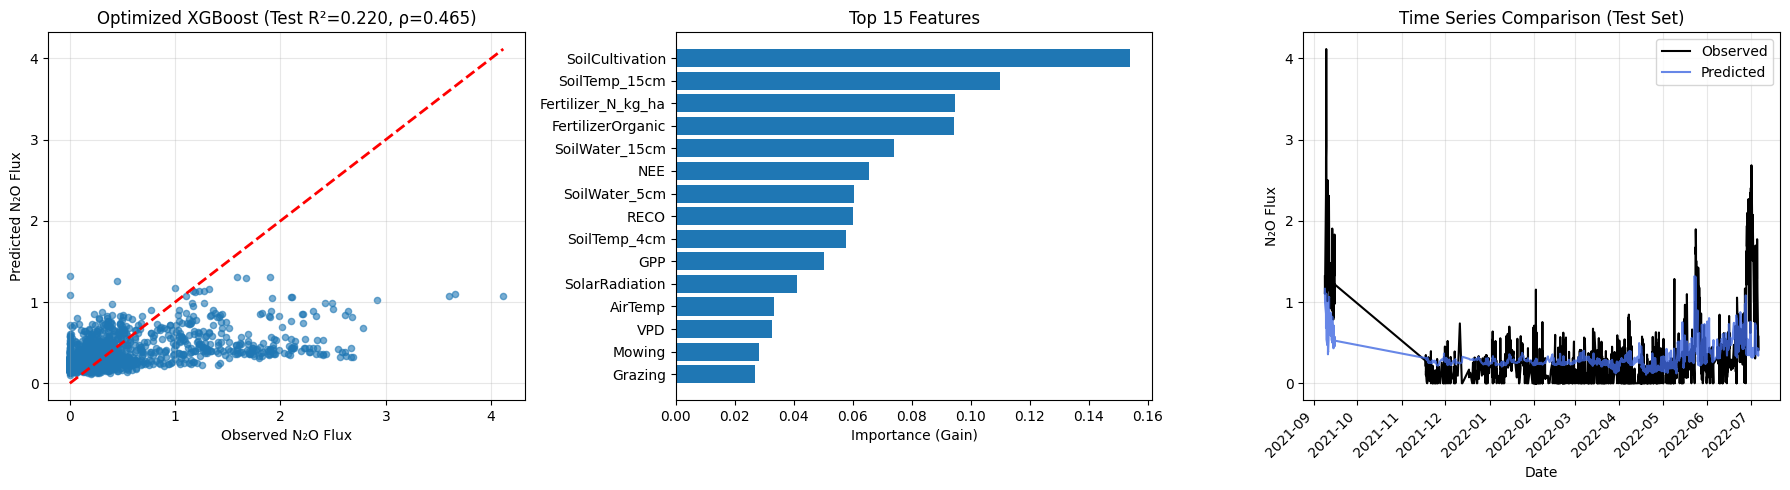


✓ Completed Hourly | Base
  Test R²: 0.2202
  Test ρ: 0.4647

OPTIMIZING: Hourly | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2014-01-01 08:15:00 → 2021-09-05 12:15:00 (17155 samples, 90.0%)
Test:      2021-09-05 12:45:00 → 2022-07-06 09:15:00 (1907 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.1022
Completed 20/500 iterations. Best CV R²: -0.1022
Completed 30/500 iterations. Best CV R²: -0.0842
Completed 40/500 iterations. Best CV R²: -0.0770
Completed 50/500 iterations. Best CV R²: -0.0770
Completed 60/500 iterations. Best CV R²: -0.0770
Completed 70/500 iterations. Best CV R²: -0.0770
Completed 80/500 iterations. Best CV R²: -0.0770
Completed 90/500 iterations. Best CV R²: -0.0770
Completed 100/500 iterations. Best CV R²: -0.0770
Completed 110/500 iterations. Best CV R²: -0.0770
Completed 120/500 iterations. Best CV R²: -

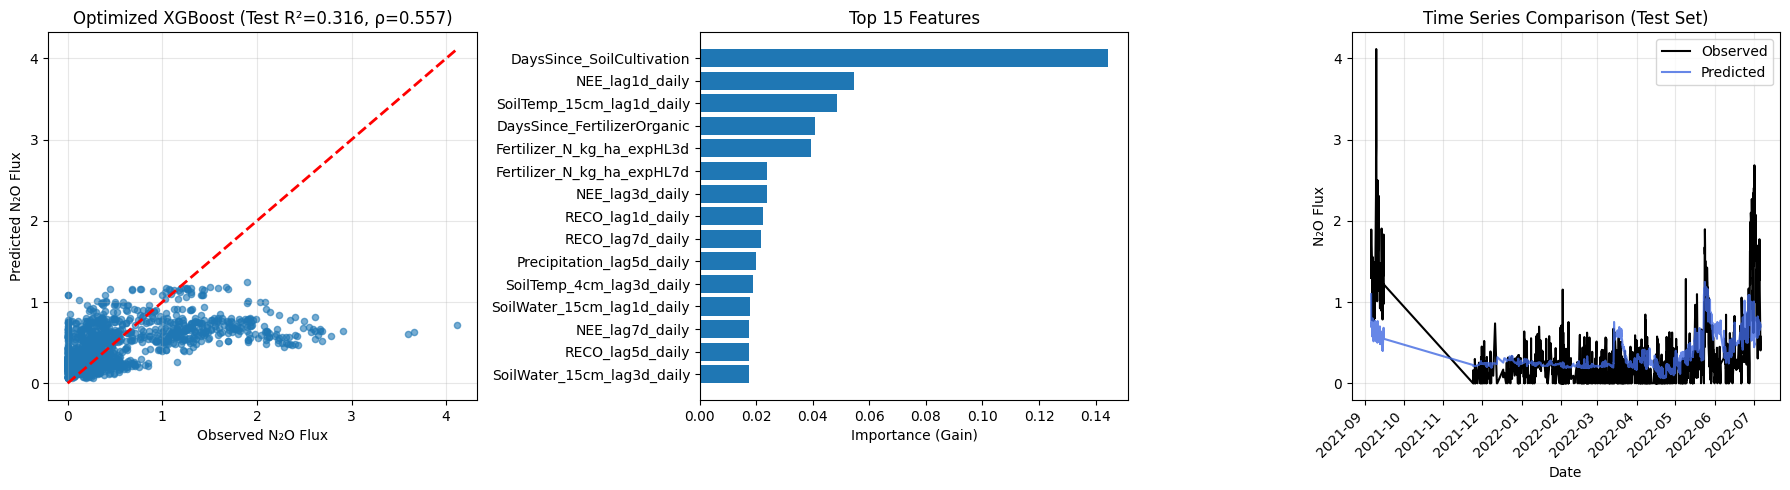


✓ Completed Hourly | Lag
  Test R²: 0.3158
  Test ρ: 0.5574

OPTIMIZING: Hourly | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2014-01-01 08:15:00 → 2021-09-05 12:15:00 (17155 samples, 90.0%)
Test:      2021-09-05 12:45:00 → 2022-07-06 09:15:00 (1907 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.0382
Completed 20/500 iterations. Best CV R²: -0.0382
Completed 30/500 iterations. Best CV R²: -0.0357
Completed 40/500 iterations. Best CV R²: -0.0332
Completed 50/500 iterations. Best CV R²: -0.0332
Completed 60/500 iterations. Best CV R²: -0.0332
Completed 70/500 iterations. Best CV R²: -0.0332
Completed 80/500 iterations. Best CV R²: -0.0278
Completed 90/500 iterations. Best CV R²: -0.0278
Completed 100/500 iterations. Best CV R²: -0.0170
Completed 110/500 iterations. Best CV R²: -0.0164
Completed 120/500 iterations. Best CV 

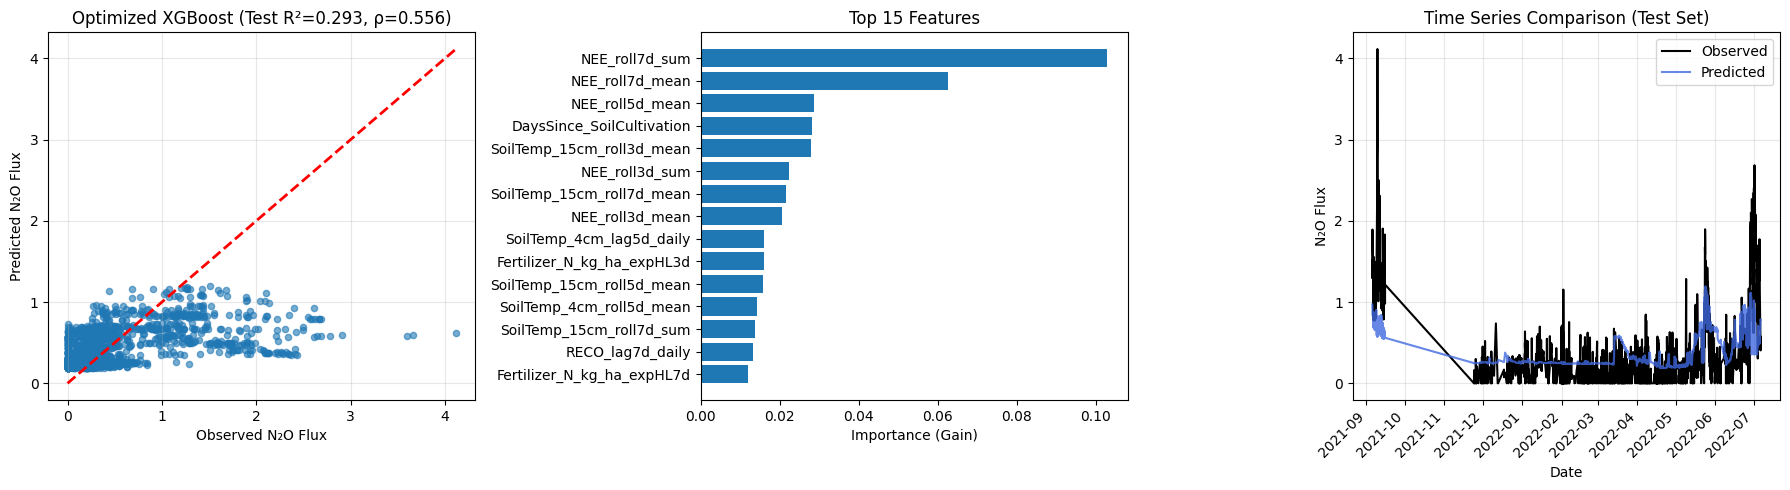


✓ Completed Hourly | Augmented
  Test R²: 0.2926
  Test ρ: 0.5560

OPTIMIZING: Daily | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2014-01-01 00:00:00 → 2021-11-24 00:00:00 (3690 samples, 90.0%)
Test:      2021-11-25 00:00:00 → 2022-07-06 00:00:00 (411 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.0258
Completed 20/500 iterations. Best CV R²: -0.0258
Completed 30/500 iterations. Best CV R²: -0.0127
Completed 40/500 iterations. Best CV R²: -0.0127
Completed 50/500 iterations. Best CV R²: -0.0127
Completed 60/500 iterations. Best CV R²: -0.0127
Completed 70/500 iterations. Best CV R²: -0.0127
Completed 80/500 iterations. Best CV R²: -0.0127
Completed 90/500 iterations. Best CV R²: -0.0127
Completed 100/500 iterations. Best CV R²: -0.0127
Completed 110/500 iterations. Best CV R²: -0.0127
Completed 120/500 iterations. Best CV R²

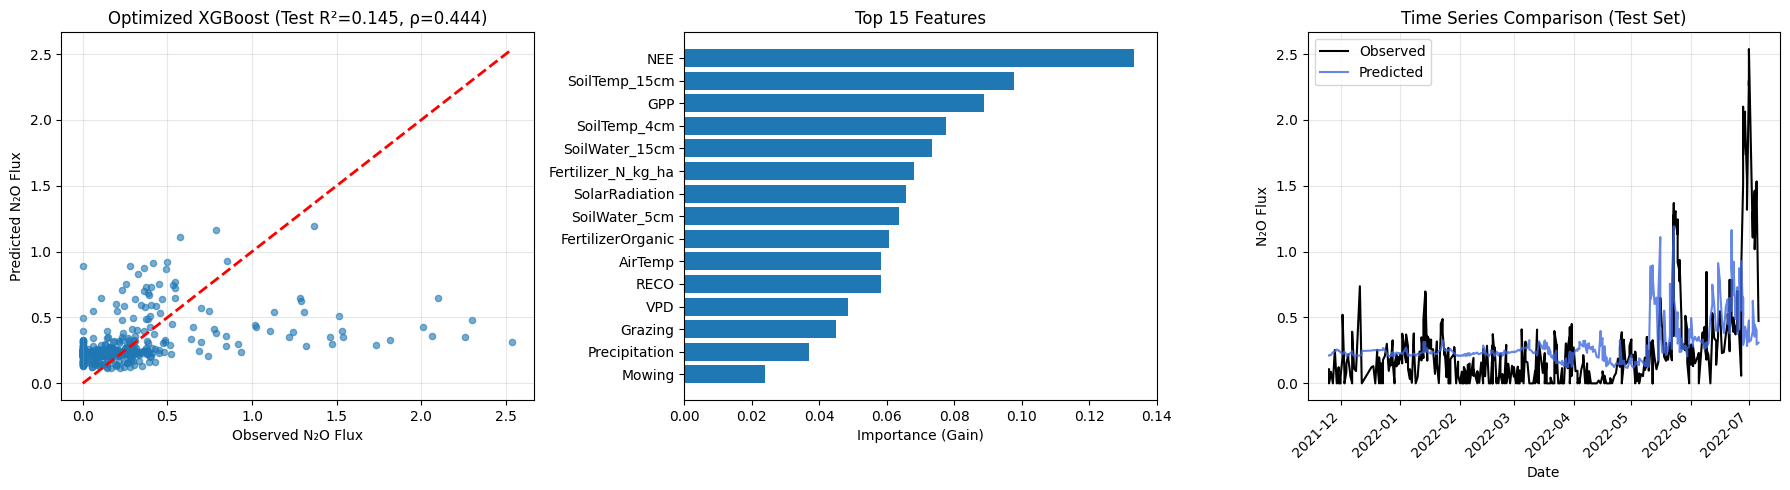


✓ Completed Daily | Base
  Test R²: 0.1452
  Test ρ: 0.4436

OPTIMIZING: Daily | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2014-01-01 00:00:00 → 2021-11-29 00:00:00 (3643 samples, 90.0%)
Test:      2021-11-29 00:00:00 → 2022-07-06 00:00:00 (405 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: 0.0032
Completed 20/500 iterations. Best CV R²: 0.0032
Completed 30/500 iterations. Best CV R²: 0.0032
Completed 40/500 iterations. Best CV R²: 0.0048
Completed 50/500 iterations. Best CV R²: 0.0048
Completed 60/500 iterations. Best CV R²: 0.0048
Completed 70/500 iterations. Best CV R²: 0.0072
Completed 80/500 iterations. Best CV R²: 0.0072
Completed 90/500 iterations. Best CV R²: 0.0072
Completed 100/500 iterations. Best CV R²: 0.0072
Completed 110/500 iterations. Best CV R²: 0.0072
Completed 120/500 iterations. Best CV R²: 0.0116
Completed

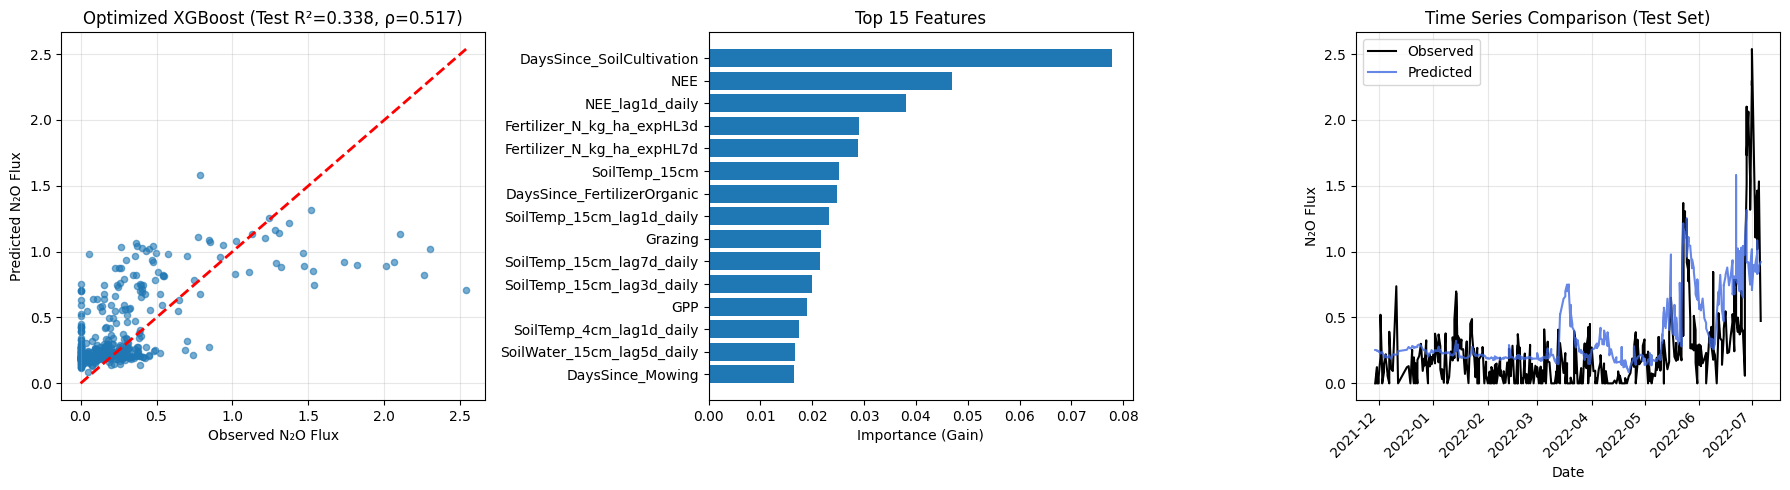


✓ Completed Daily | Lag
  Test R²: 0.3380
  Test ρ: 0.5172

OPTIMIZING: Daily | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2014-01-01 00:00:00 → 2021-11-29 00:00:00 (3643 samples, 90.0%)
Test:      2021-11-29 00:00:00 → 2022-07-06 00:00:00 (405 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.0019
Completed 20/500 iterations. Best CV R²: -0.0019
Completed 30/500 iterations. Best CV R²: 0.0006
Completed 40/500 iterations. Best CV R²: 0.0006
Completed 50/500 iterations. Best CV R²: 0.0006
Completed 60/500 iterations. Best CV R²: 0.0068
Completed 70/500 iterations. Best CV R²: 0.0068
Completed 80/500 iterations. Best CV R²: 0.0068
Completed 90/500 iterations. Best CV R²: 0.0068
Completed 100/500 iterations. Best CV R²: 0.0084
Completed 110/500 iterations. Best CV R²: 0.0084
Completed 120/500 iterations. Best CV R²: 0.0084
Co

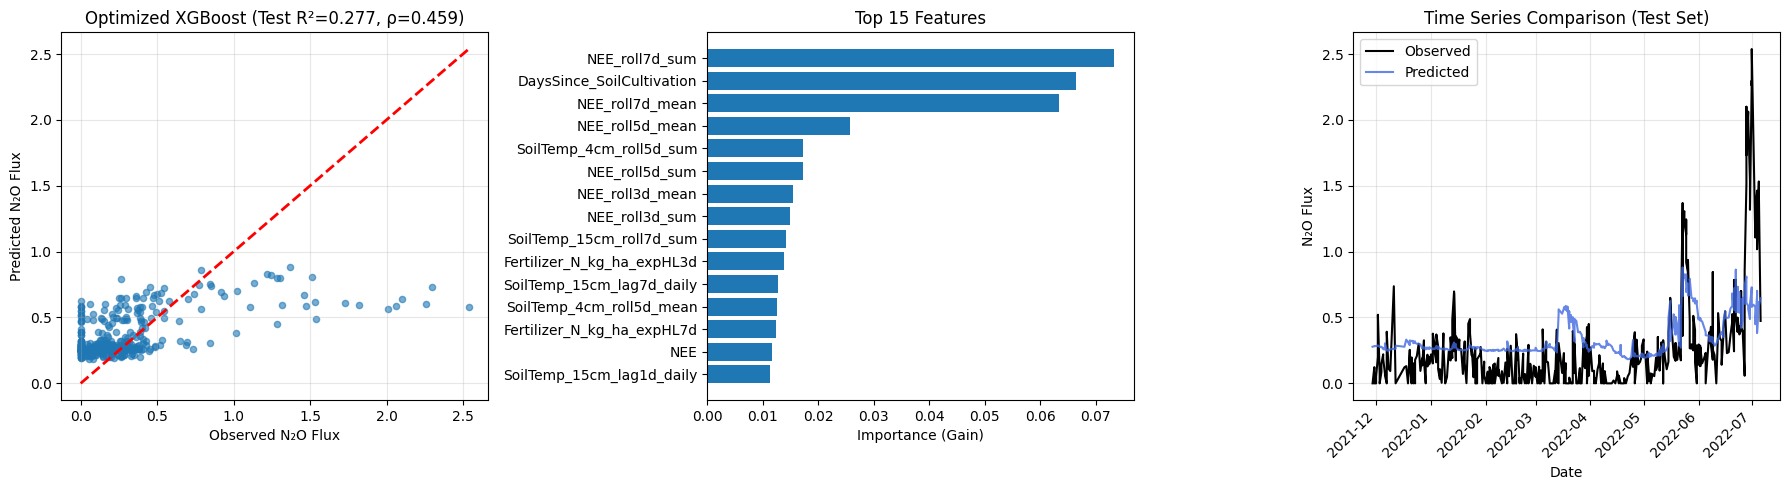


✓ Completed Daily | Augmented
  Test R²: 0.2771
  Test ρ: 0.4589


In [211]:
configurations = [
    ("Hourly", "Base", chamau_lag, base_predictors),
    ("Hourly", "Lag", chamau_lag, lag_predictors),
    ("Hourly", "Augmented", chamau_lag, augmented_predictors),
    ("Daily", "Base", chamau_daily, base_predictors),
    ("Daily", "Lag", chamau_daily, lag_predictors),
    ("Daily", "Augmented", chamau_daily, augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1,
        search_type='bayesian',
        n_iter=500,
        random_state=42,
        n_cv_splits=9
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        predictors=predictors,
        best_params=best_params,
        random_state=42,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

## Rerun original model for comparison

In [212]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_xgb_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        n_estimators=300,
        random_state=42,
        plot=False
    )
    

    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.070
  Spearman ρ:        0.177

Running original Hourly | Lag...
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.281
  Spearman ρ:        0.534

Running original Hourly | Augmented...
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.289
  Spearman ρ:        0.530

Running original Daily | Base...
Train period: 2014-01-01 00:00:00 → 2021-08-10 00:00:00
Test  period: 2021-08-10 00:00:00 → 2022-07-0

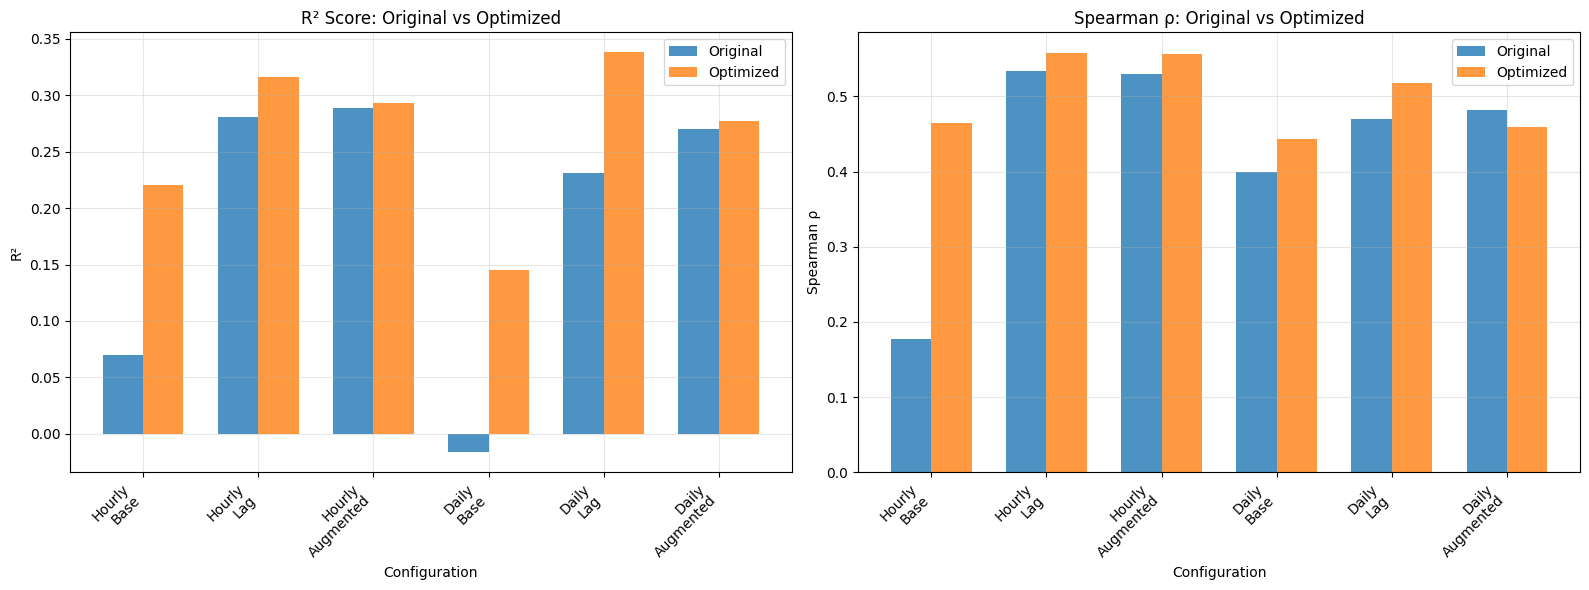

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save best parameters

In [214]:
# Define dataset name
dataset_name = "Chamau"

# Create dataset subfolder inside existing xgboost_params folder
save_dir = os.path.join('xgboost_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to xgboost_params/Chamau!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 30
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/xgboost_params/Chamau

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +0.1504
Hourly          | Lag                  | ✓ OPTIMIZED  | ΔR²: +0.0352
Hourly          | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.0040
Daily           | Base                 | ✓ OPTIMIZED  | ΔR²: +0.1616
Daily           | Lag                  | ✓ OPTIMIZED  | ΔR²: +0.1068
Daily           | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.0071


# Experiment 2: Oensingen 2021-23 dataset

## Fix index and define predictors

In [234]:
# FIX TIMESTAMP
oensingen_2_lag['Timestamp'] = pd.to_datetime(oensingen_2_lag['Timestamp'])
oensingen_2_lag = oensingen_2_lag.set_index('Timestamp').sort_index()

oensingen_2_daily['Date'] = pd.to_datetime(oensingen_2_daily['Date'])
oensingen_2_daily = oensingen_2_daily.set_index('Date').sort_index()

In [235]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation", "Fertilizer_N_kg_ha"
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

## Run finetuning


OPTIMIZING: Hourly | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2022-08-30 11:45:00 → 2023-08-24 11:45:00 (5930 samples, 90.0%)
Test:      2023-08-24 14:45:00 → 2023-10-05 12:15:00 (659 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -2.1590
Completed 20/500 iterations. Best CV R²: -2.1590
Completed 30/500 iterations. Best CV R²: -2.1345
Completed 40/500 iterations. Best CV R²: -2.1275
Completed 50/500 iterations. Best CV R²: -2.1275
Completed 60/500 iterations. Best CV R²: -2.1275
Completed 70/500 iterations. Best CV R²: -2.1275
Completed 80/500 iterations. Best CV R²: -2.1275
Completed 90/500 iterations. Best CV R²: -2.1275
Completed 100/500 iterations. Best CV R²: -2.0839
Completed 110/500 iterations. Best CV R²: -2.0777
Completed 120/500 iterations. Best CV R²: -2.0777
Completed 130/500 iterations. Best CV R²: -2.0599
Comple

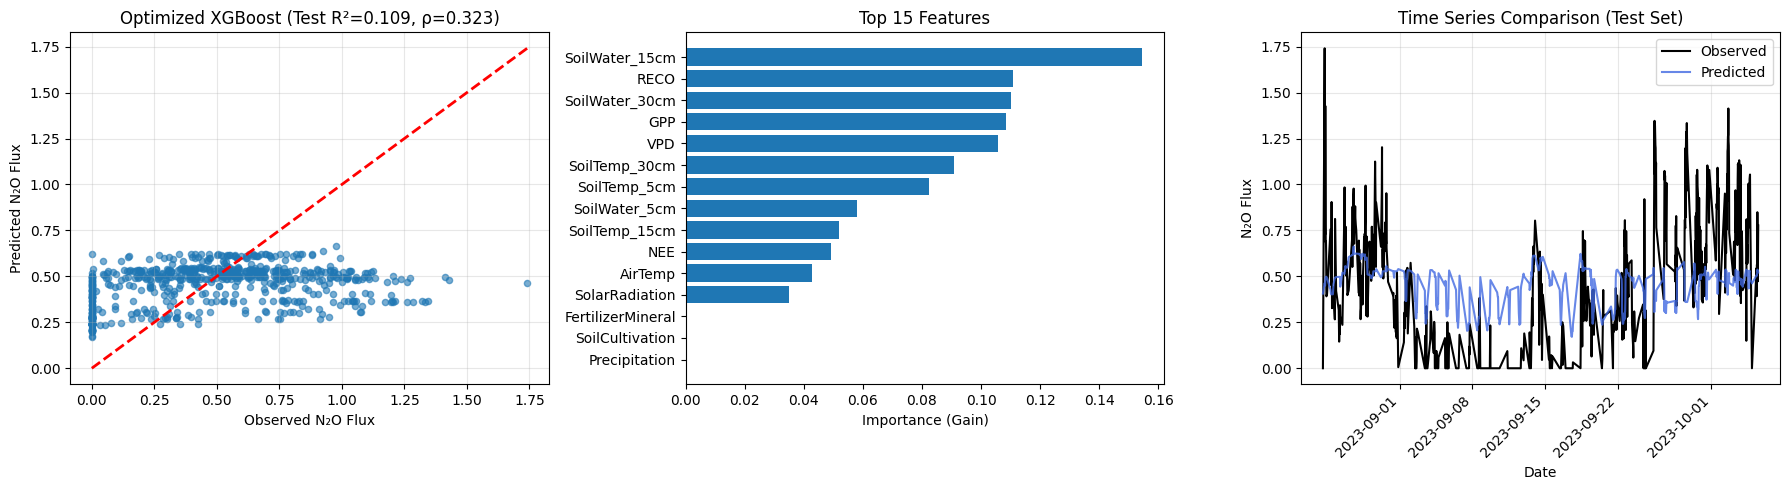


✓ Completed Hourly | Base
  Test R²: 0.1094
  Test ρ: 0.3227

OPTIMIZING: Hourly | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2022-08-30 11:45:00 → 2023-08-24 11:45:00 (5930 samples, 90.0%)
Test:      2023-08-24 14:45:00 → 2023-10-05 12:15:00 (659 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.6088
Completed 20/500 iterations. Best CV R²: -0.5657
Completed 30/500 iterations. Best CV R²: -0.5657
Completed 40/500 iterations. Best CV R²: -0.5153
Completed 50/500 iterations. Best CV R²: -0.5153
Completed 60/500 iterations. Best CV R²: -0.5153
Completed 70/500 iterations. Best CV R²: -0.5153
Completed 80/500 iterations. Best CV R²: -0.5153
Completed 90/500 iterations. Best CV R²: -0.5081
Completed 100/500 iterations. Best CV R²: -0.5081
Completed 110/500 iterations. Best CV R²: -0.4946
Completed 120/500 iterations. Best CV R²: -0.

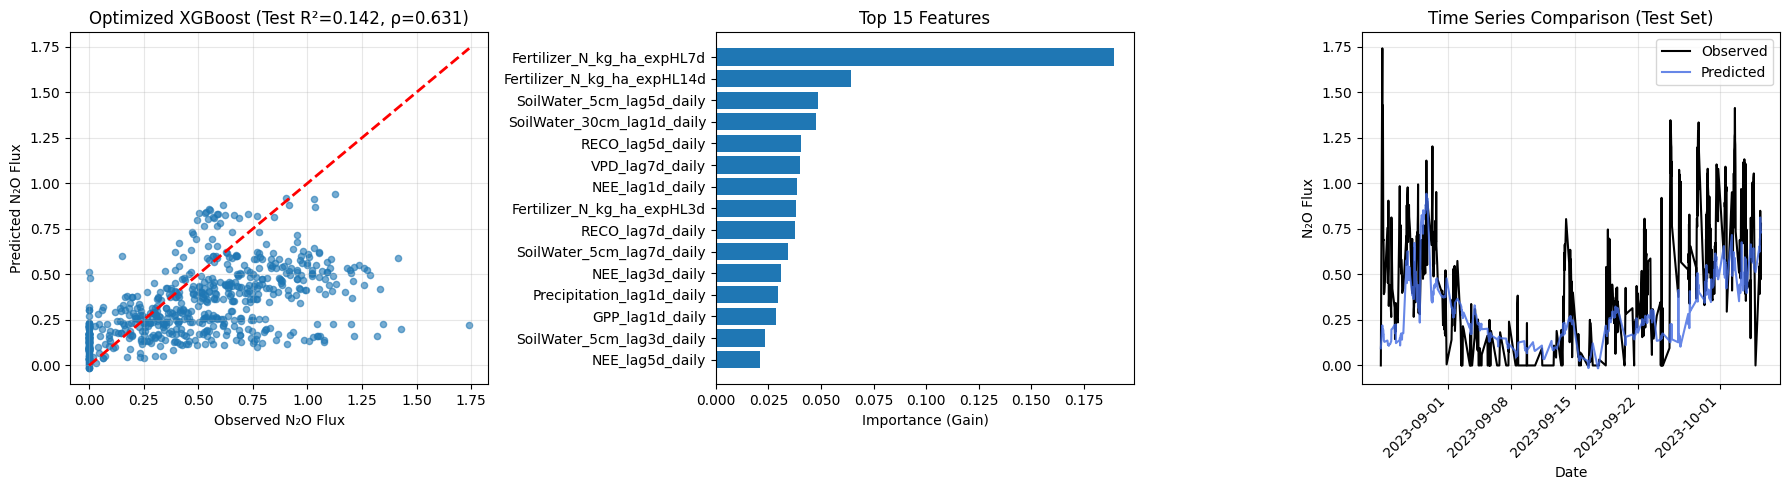


✓ Completed Hourly | Lag
  Test R²: 0.1421
  Test ρ: 0.6313

OPTIMIZING: Hourly | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2022-08-30 11:45:00 → 2023-08-24 11:45:00 (5930 samples, 90.0%)
Test:      2023-08-24 14:45:00 → 2023-10-05 12:15:00 (659 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.5695
Completed 20/500 iterations. Best CV R²: -0.5695
Completed 30/500 iterations. Best CV R²: -0.5609
Completed 40/500 iterations. Best CV R²: -0.5440
Completed 50/500 iterations. Best CV R²: -0.5440
Completed 60/500 iterations. Best CV R²: -0.5440
Completed 70/500 iterations. Best CV R²: -0.5440
Completed 80/500 iterations. Best CV R²: -0.5435
Completed 90/500 iterations. Best CV R²: -0.5435
Completed 100/500 iterations. Best CV R²: -0.5435
Completed 110/500 iterations. Best CV R²: -0.5435
Completed 120/500 iterations. Best CV R²

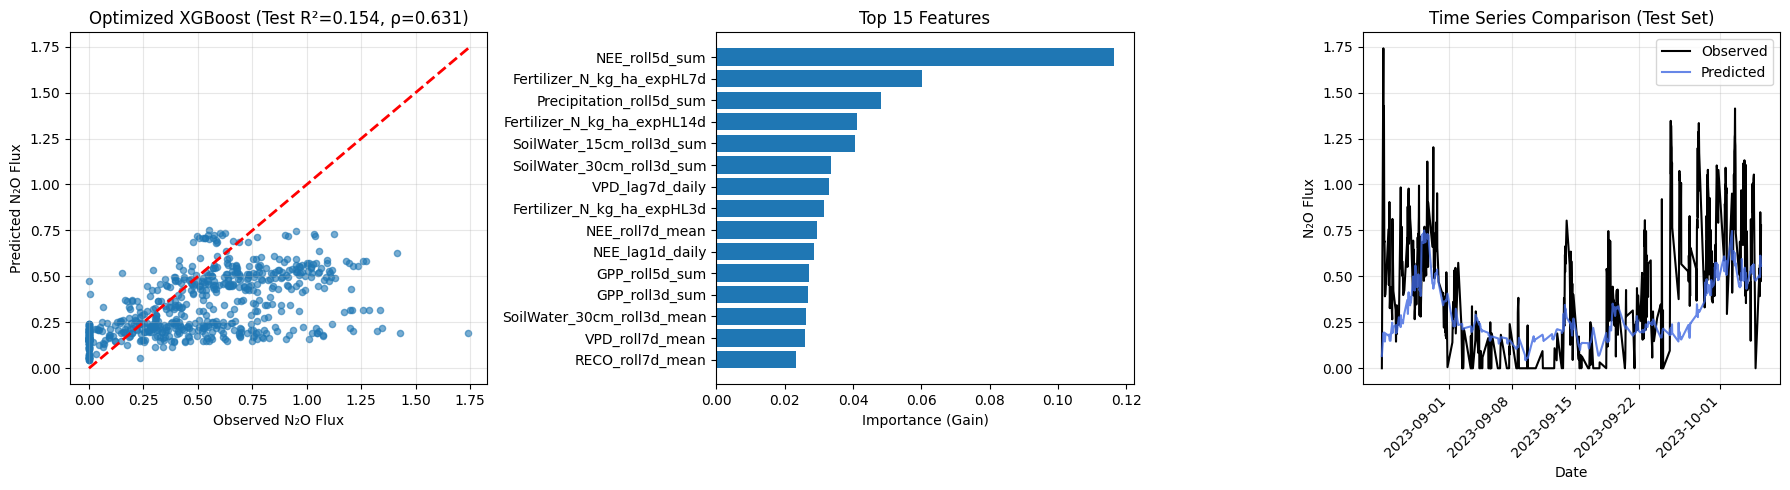


✓ Completed Hourly | Augmented
  Test R²: 0.1544
  Test ρ: 0.6306

OPTIMIZING: Daily | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2022-08-30 00:00:00 → 2023-08-28 00:00:00 (336 samples, 89.8%)
Test:      2023-08-29 00:00:00 → 2023-10-05 00:00:00 (38 samples, 10.2%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 10/500 iterations. Best CV R²: -1.1974
Completed 20/500 iterations. Best CV R²: -1.0186
Completed 30/500 iterations. Best CV R²: -1.0186
Completed 40/500 iterations. Best CV R²: -1.0186
Completed 50/500 iterations. Best CV R²: -1.0186
Completed 60/500 iterations. Best CV R²: -1.0186
Completed 70/500 iterations. Best CV R²: -1.0186
Completed 80/500 iterations. Best CV R²: -1.0186
Completed 90/500 iterations. Best CV R²: -1.0186
Completed 100/500 iterations. Best CV R²: -1.0186
Completed 110/500 iterations. Best CV R²: -1.0186
Completed 120/500 iterations. Best CV R²: -0.9471
Completed 130/500 iterations. Best CV R²: -0.9471
Completed 140/500 iterations. Best CV R²: -0.9471
Completed 150/500 iterations. Best CV R²: -0.9471
Completed 160/500 iterations. Best CV R²: -0.9471
Completed 170/500 iterations. Best CV R²: -0.9471
Completed 180/500 iterations. Best CV R²: -0.9471
Completed 190/500 iterations. Best CV R²: -0.9471
Completed 200/500 iterations. Best CV R²: -0.9471
Completed

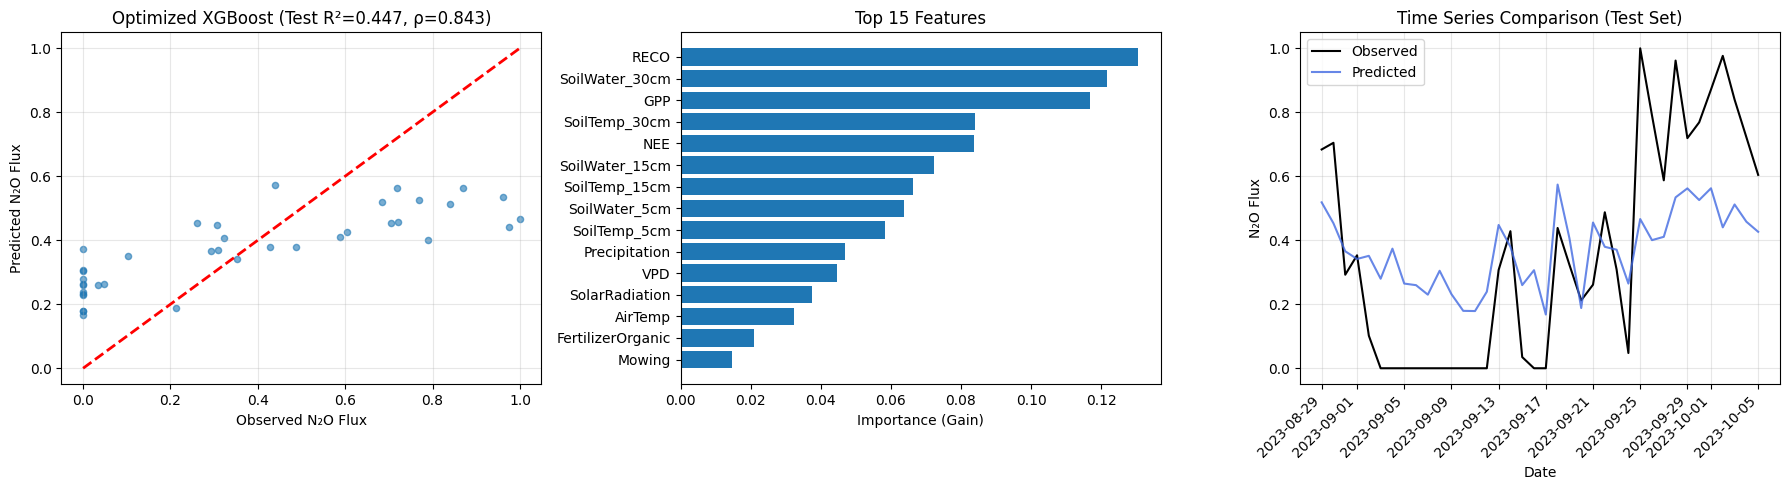


✓ Completed Daily | Base
  Test R²: 0.4467
  Test ρ: 0.8427

OPTIMIZING: Daily | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2022-09-06 00:00:00 → 2023-08-29 00:00:00 (330 samples, 89.9%)
Test:      2023-08-30 00:00:00 → 2023-10-05 00:00:00 (37 samples, 10.1%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.7353
Completed 20/500 iterations. Best CV R²: -0.7353
Completed 30/500 iterations. Best CV R²: -0.7132
Completed 40/500 iterations. Best CV R²: -0.7132
Completed 50/500 iterations. Best CV R²: -0.7132
Completed 60/500 iterations. Best CV R²: -0.6590
Completed 70/500 iterations. Best CV R²: -0.6590
Completed 80/500 iterations. Best CV R²: -0.6590
Completed 90/500 iterations. Best CV R²: -0.6484
Completed 100/500 iterations. Best CV R²: -0.6484
Completed 110/500 iterations. Best CV R²: -0.6484
Completed 120/500 iterations. Best CV R²: -0.6484

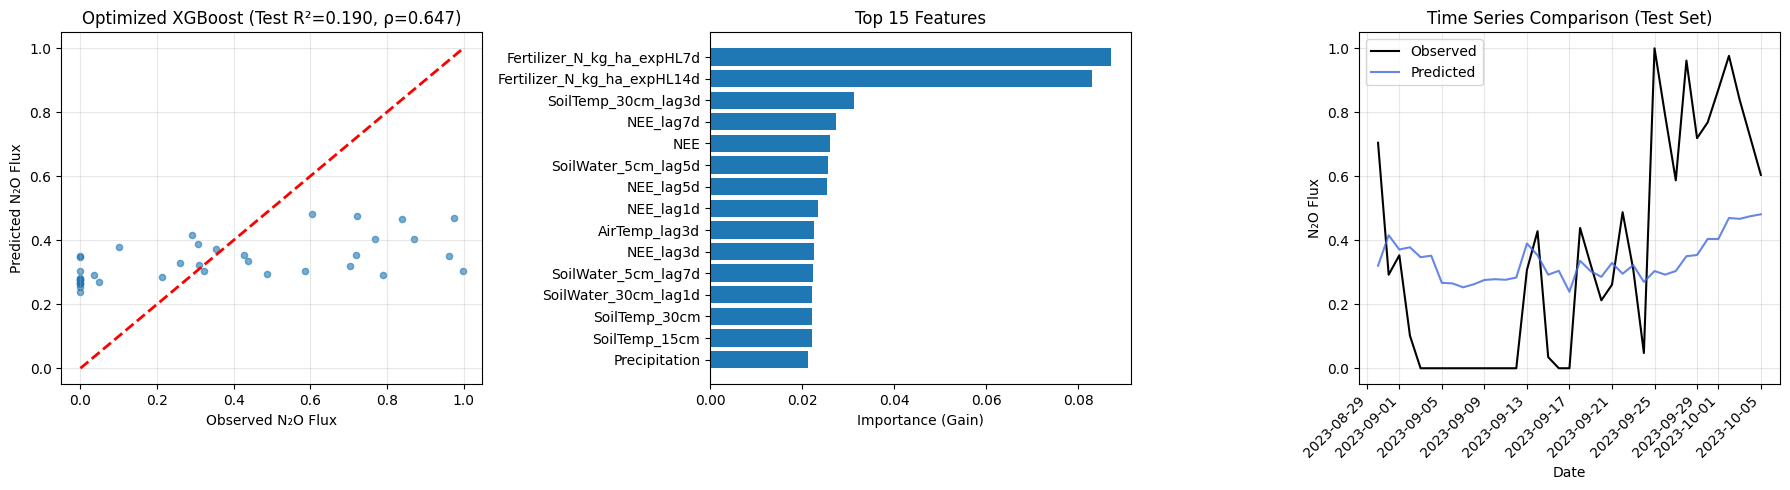


✓ Completed Daily | Lag
  Test R²: 0.1900
  Test ρ: 0.6468

OPTIMIZING: Daily | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2022-09-06 00:00:00 → 2023-08-29 00:00:00 (330 samples, 89.9%)
Test:      2023-08-30 00:00:00 → 2023-10-05 00:00:00 (37 samples, 10.1%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 10/500 iterations. Best CV R²: -0.7289
Completed 20/500 iterations. Best CV R²: -0.7289
Completed 30/500 iterations. Best CV R²: -0.6957


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 40/500 iterations. Best CV R²: -0.6422


...

Completed 470/500 iterations. Best CV R²: -0.5829
Completed 480/500 iterations. Best CV R²: -0.5829


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 490/500 iterations. Best CV R²: -0.5829


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 500/500 iterations. Best CV R²: -0.5829

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.9
  gamma: 0.5
  learning_rate: 0.01
  max_depth: 8
  min_child_weight: 5
  n_estimators: 100
  subsample: 0.9

Best CV R² (mean across 9 folds): -0.5829

Training final model on 330 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): 0.1589
Spearman ρ:        0.5409


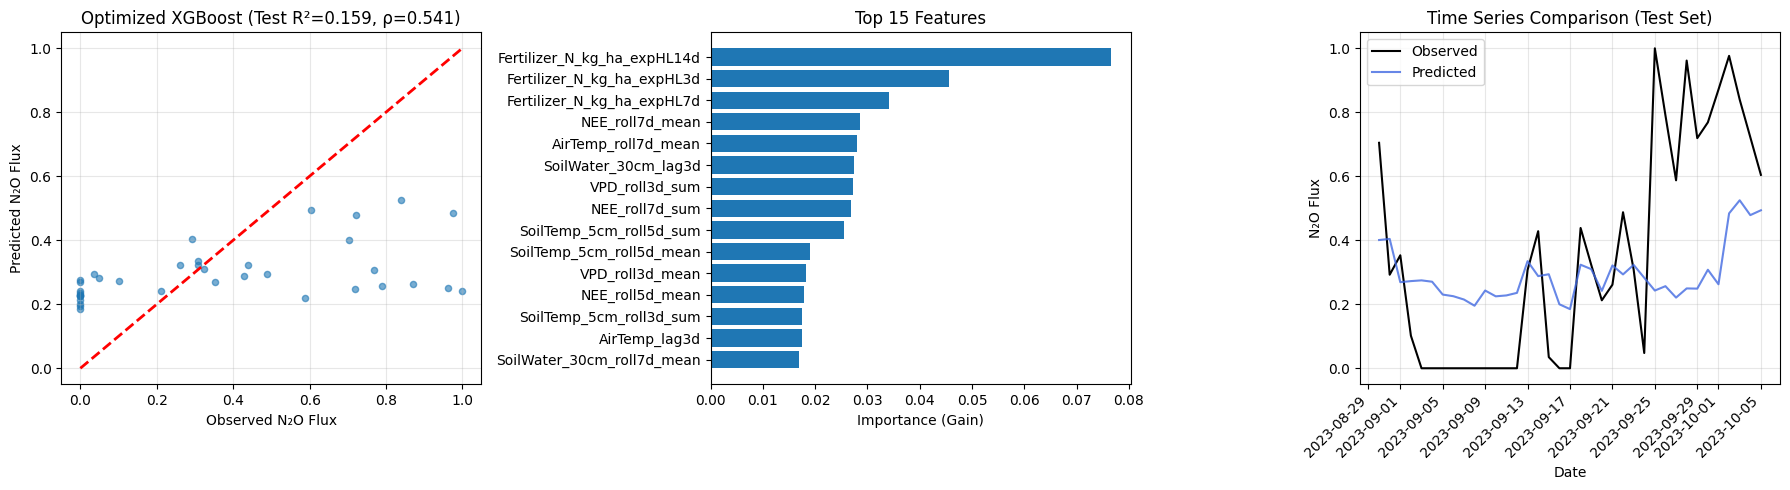


✓ Completed Daily | Augmented
  Test R²: 0.1589
  Test ρ: 0.5409


In [236]:
configurations = [
    ("Hourly", "Base", oensingen_2_lag, base_predictors),
    ("Hourly", "Lag", oensingen_2_lag, hourly_lag_predictors),
    ("Hourly", "Augmented", oensingen_2_lag, hourly_augmented_predictors),
    ("Daily", "Base", oensingen_2_daily, base_predictors),
    ("Daily", "Lag", oensingen_2_daily, daily_lag_predictors),
    ("Daily", "Augmented", oensingen_2_daily, daily_augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1,
        search_type='bayesian',
        n_iter=500,
        random_state=42,
        n_cv_splits=9
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        predictors=predictors,
        best_params=best_params,
        random_state=42,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

## Rerun original model for comparison

In [237]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_xgb_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        n_estimators=300,
        random_state=42,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.060
  Spearman ρ:        0.336

Running original Hourly | Lag...
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.205
  Spearman ρ:        0.697

Running original Hourly | Augmented...
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.046
  Spearman ρ:        0.658

Running original Daily | Base...
Train period: 2022-08-30 00:00:00 → 2023-08-28 00:00:00
Test  period: 2023-08-29 00:00:00 → 2023-10-0

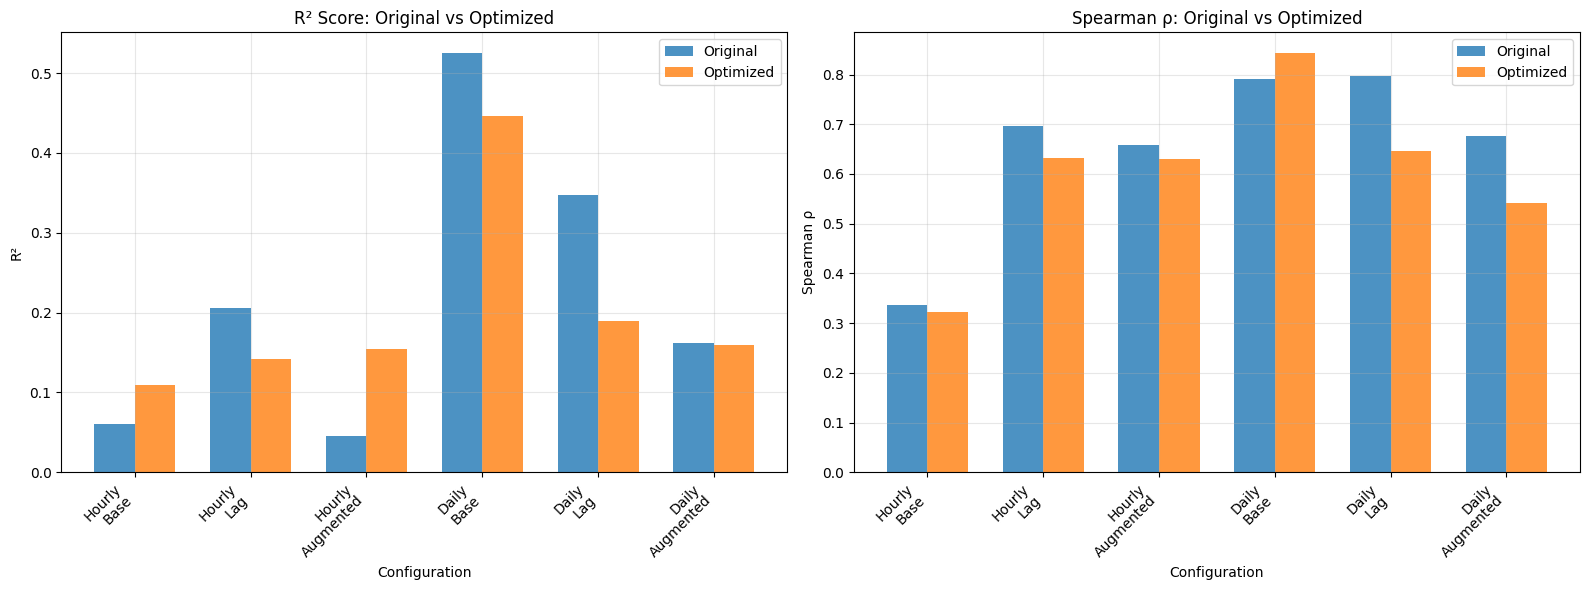

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save best parameters

In [239]:
# Define dataset name
dataset_name = "Oensingen_2021-23"

# Create dataset subfolder inside existing xgboost_params folder
save_dir = os.path.join('xgboost_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to xgboost_params/Oensingen_2021-23!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 30
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/xgboost_params/Oensingen_2021-23

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +0.0494
Hourly          | Lag                  | ✓ ORIGINAL   | ΔR²: -0.0632
Hourly          | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.1084
Daily           | Base                 | ✓ ORIGINAL   | ΔR²: -0.0782
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -0.1574
Daily           | Augmented            | ✓ ORIGINAL   | ΔR²: -0.0027


# Experiment 3: Aeschi dataset

## Fix index and define predictors

In [218]:
# FIX TIMESTAMP
aeschi_lag['Timestamp'] = pd.to_datetime(aeschi_lag['Timestamp'])
aeschi_lag = aeschi_lag.set_index('Timestamp').sort_index()

aeschi_daily['Date'] = pd.to_datetime(aeschi_daily['Date'])
aeschi_daily = aeschi_daily.set_index('Date').sort_index()

In [219]:
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing",
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "DaysSince_Mowing"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "DaysSince_Mowing"
]

## Run finetuning


OPTIMIZING: Hourly | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2019-05-19 19:45:00 → 2020-10-20 07:15:00 (5904 samples, 90.0%)
Test:      2020-10-20 07:45:00 → 2020-11-02 23:45:00 (657 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -6.9458


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -5.4737


...

Completed 480/500 iterations. Best CV R²: -0.9684


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -0.9684


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -0.9684

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.9
  gamma: 0
  learning_rate: 0.1
  max_depth: 4
  min_child_weight: 1
  n_estimators: 100
  subsample: 0.9

Best CV R² (mean across 9 folds): -0.9684

Training final model on 5904 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -1.4758
Spearman ρ:        0.0903


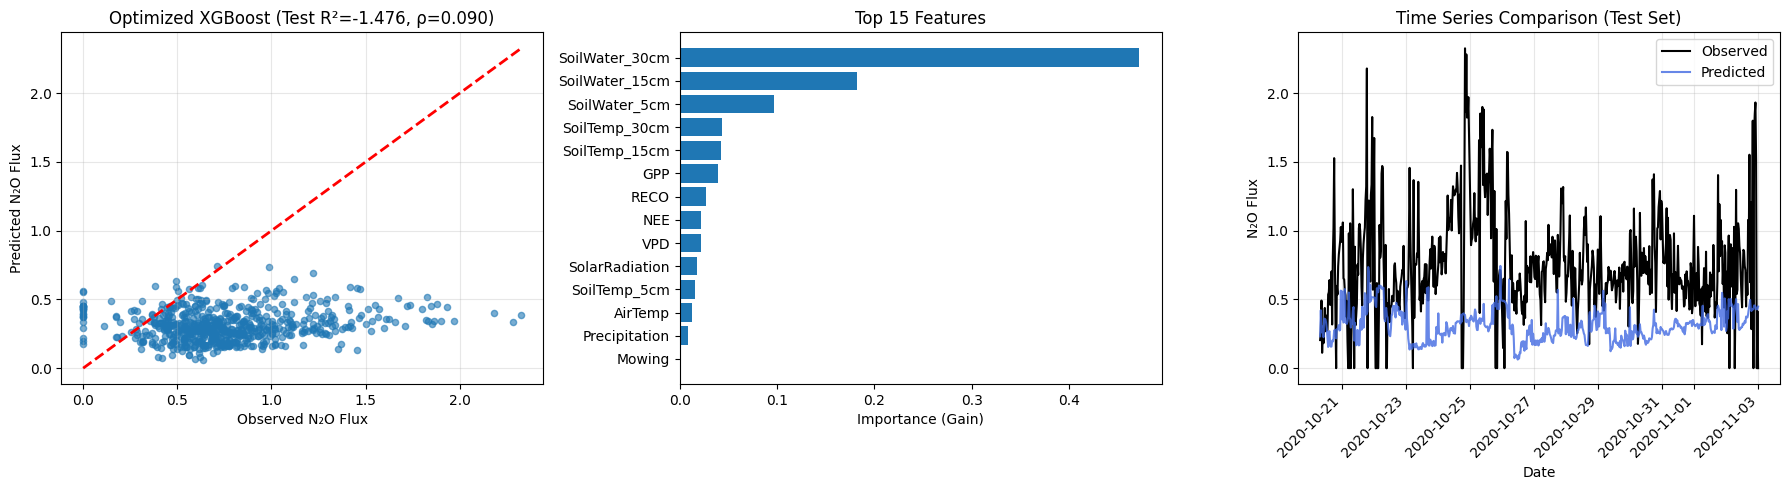


✓ Completed Hourly | Base
  Test R²: -1.4758
  Test ρ: 0.0903

OPTIMIZING: Hourly | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2019-05-24 01:45:00 → 2020-10-21 06:45:00 (5488 samples, 90.0%)
Test:      2020-10-21 07:15:00 → 2020-11-02 23:45:00 (610 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -7.5984


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -2.0070


...

Completed 480/500 iterations. Best CV R²: -1.6016


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -1.6016


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -1.6016

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.8
  gamma: 0
  learning_rate: 0.1
  max_depth: 8
  min_child_weight: 1
  n_estimators: 100
  subsample: 0.9

Best CV R² (mean across 9 folds): -1.6016

Training final model on 5488 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -1.3598
Spearman ρ:        0.1675


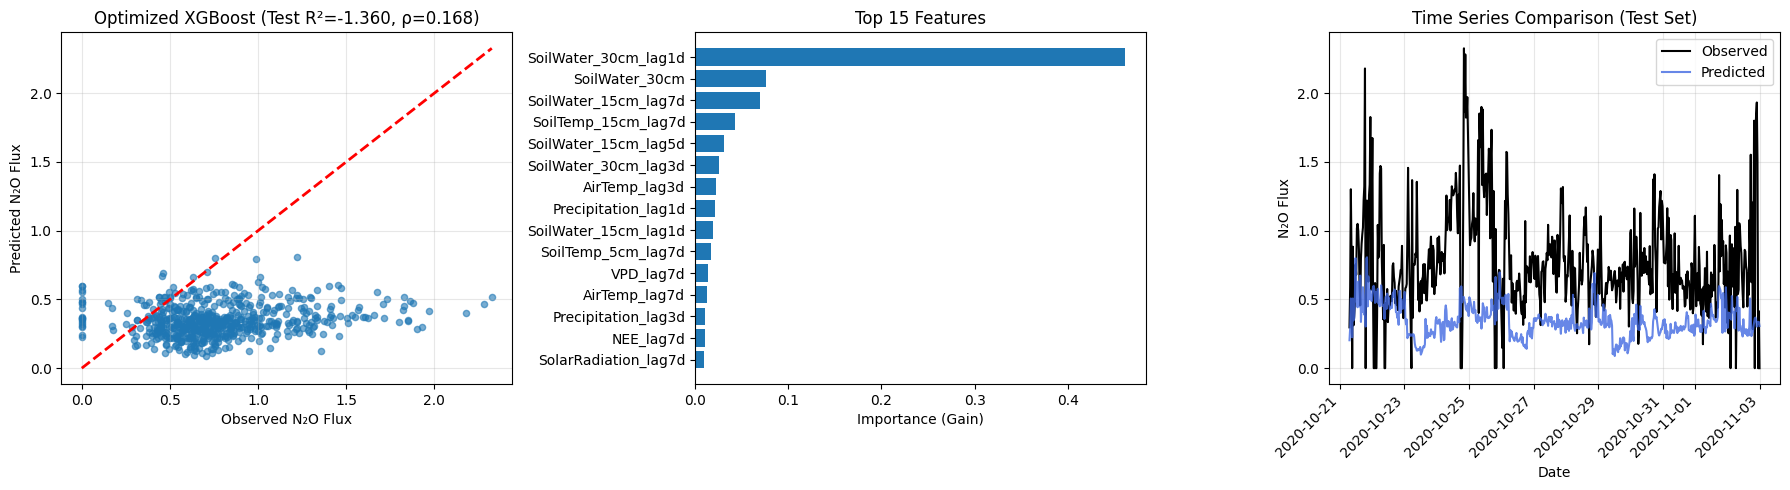


✓ Completed Hourly | Lag
  Test R²: -1.3598
  Test ρ: 0.1675

OPTIMIZING: Hourly | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2019-05-24 01:45:00 → 2020-10-21 06:45:00 (5488 samples, 90.0%)
Test:      2020-10-21 07:15:00 → 2020-11-02 23:45:00 (610 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -3.8825


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -3.8245


...

Completed 480/500 iterations. Best CV R²: -2.0082


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -2.0082


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -1.9431

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.9
  gamma: 0
  learning_rate: 0.05
  max_depth: 8
  min_child_weight: 5
  n_estimators: 100
  subsample: 0.8

Best CV R² (mean across 9 folds): -1.9431

Training final model on 5488 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -1.2251
Spearman ρ:        0.1951


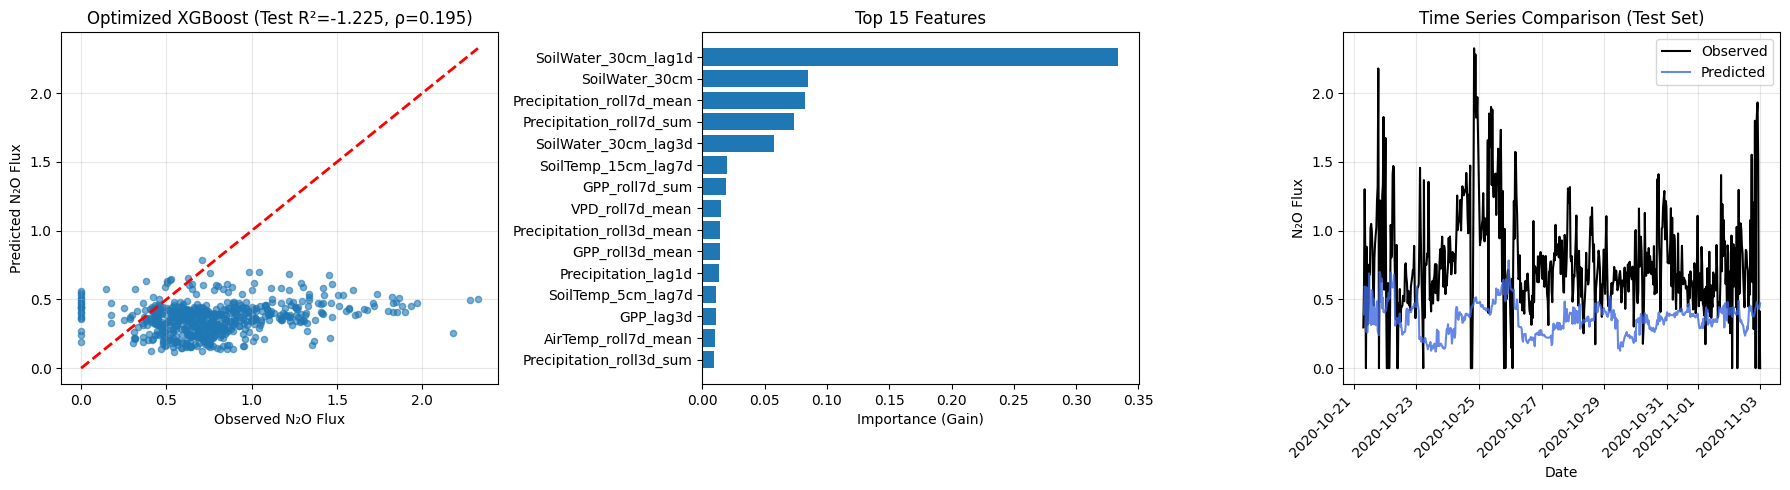


✓ Completed Hourly | Augmented
  Test R²: -1.2251
  Test ρ: 0.1951

OPTIMIZING: Daily | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2019-05-17 00:00:00 → 2020-10-08 00:00:00 (216 samples, 89.6%)
Test:      2020-10-09 00:00:00 → 2020-11-02 00:00:00 (25 samples, 10.4%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -1603.3609


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -1603.3609


...

Completed 480/500 iterations. Best CV R²: -1076.0239


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -1076.0239


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -1076.0239

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.6
  gamma: 0.1
  learning_rate: 0.2
  max_depth: 5
  min_child_weight: 1
  n_estimators: 300
  subsample: 0.9

Best CV R² (mean across 9 folds): -1076.0239

Training final model on 216 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -1.3751
Spearman ρ:        -0.6239


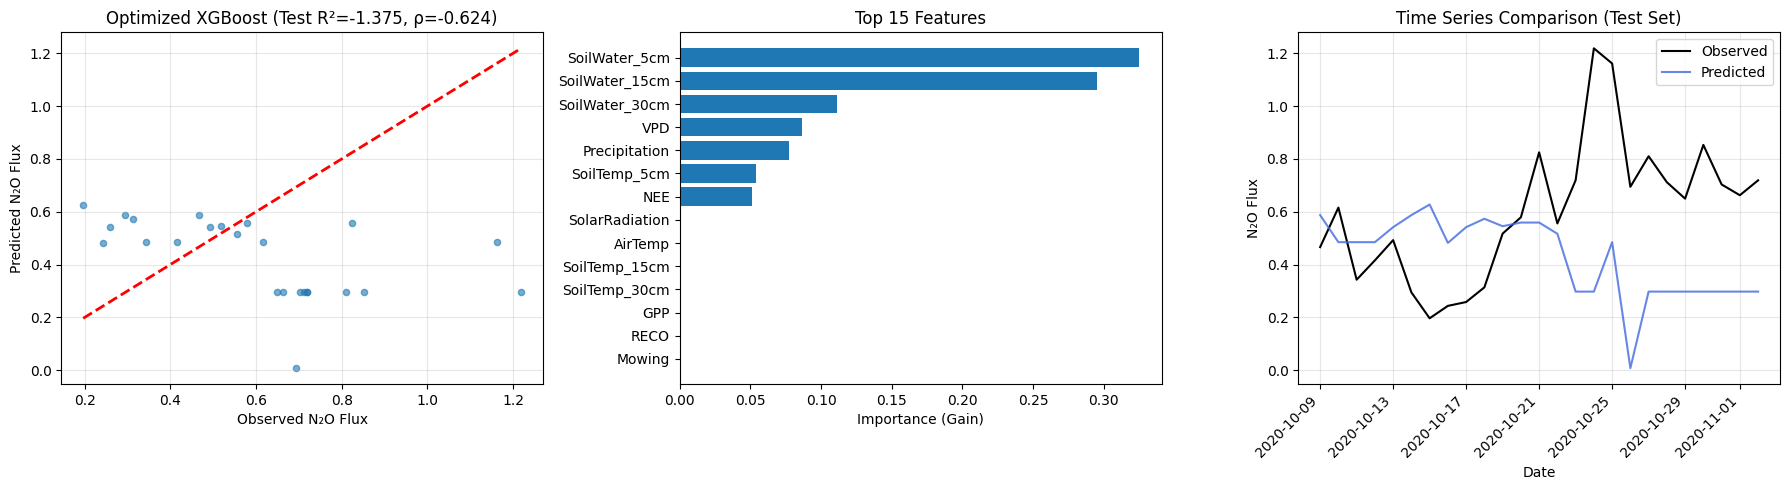


✓ Completed Daily | Base
  Test R²: -1.3751
  Test ρ: -0.6239

OPTIMIZING: Daily | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2019-05-24 00:00:00 → 2020-10-10 00:00:00 (207 samples, 90.0%)
Test:      2020-10-11 00:00:00 → 2020-11-02 00:00:00 (23 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -1124.9304


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -586.1854


...

Completed 480/500 iterations. Best CV R²: -586.1854


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -586.1854


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -586.1854

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.7
  gamma: 0.1
  learning_rate: 0.2
  max_depth: 3
  min_child_weight: 3
  n_estimators: 100
  subsample: 0.6

Best CV R² (mean across 9 folds): -586.1854

Training final model on 207 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -1.3203
Spearman ρ:        -0.4825


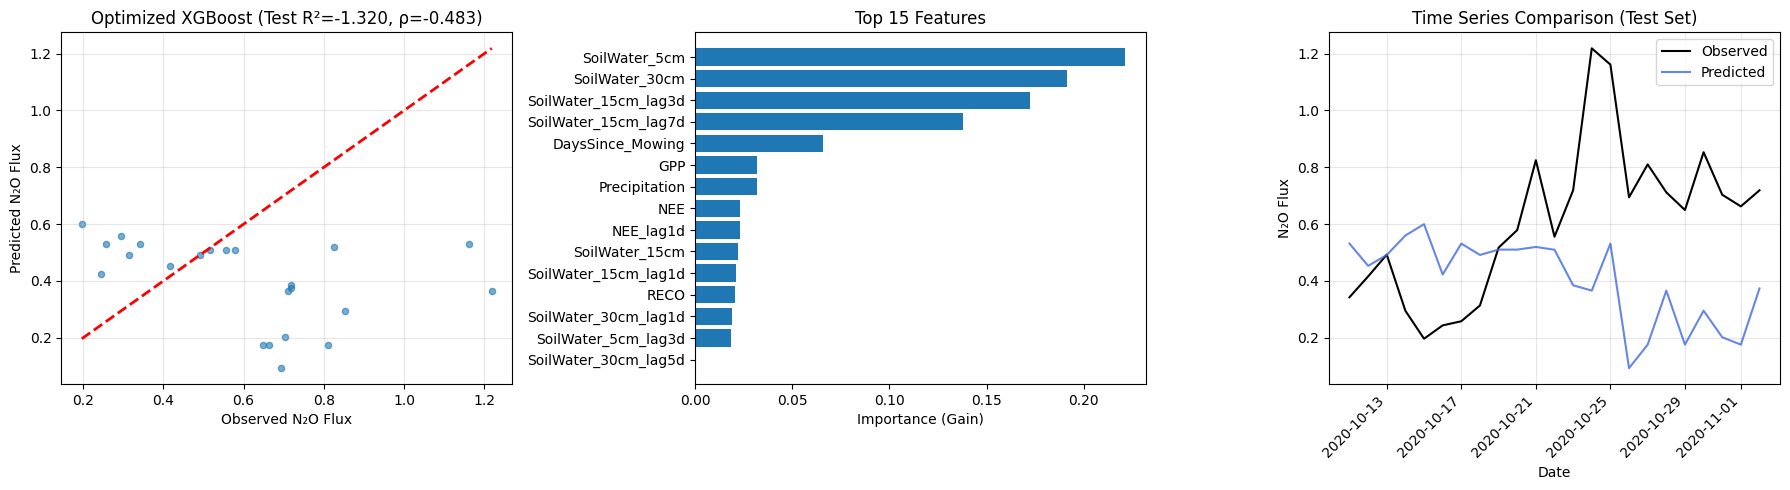


✓ Completed Daily | Lag
  Test R²: -1.3203
  Test ρ: -0.4825

OPTIMIZING: Daily | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2019-05-24 00:00:00 → 2020-10-10 00:00:00 (207 samples, 90.0%)
Test:      2020-10-11 00:00:00 → 2020-11-02 00:00:00 (23 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -1226.7235


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -1226.7235


...

Completed 480/500 iterations. Best CV R²: -1006.7900


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -1006.7900


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_87897/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -1006.7900

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.6
  gamma: 0
  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 1
  n_estimators: 300
  subsample: 0.9

Best CV R² (mean across 9 folds): -1006.7900

Training final model on 207 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -0.8851
Spearman ρ:        -0.4921


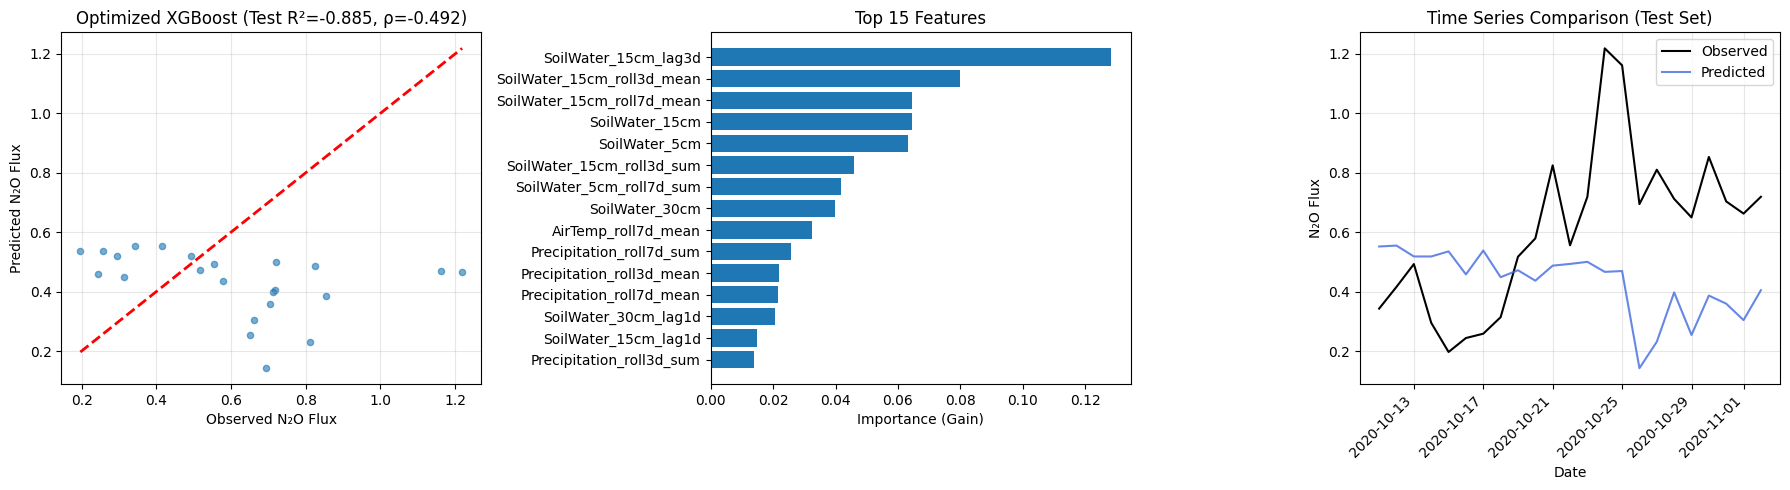


✓ Completed Daily | Augmented
  Test R²: -0.8851
  Test ρ: -0.4921


In [220]:
configurations = [
    ("Hourly", "Base", aeschi_lag, base_predictors),
    ("Hourly", "Lag", aeschi_lag, lag_predictors),
    ("Hourly", "Augmented", aeschi_lag, augmented_predictors),
    ("Daily", "Base", aeschi_daily, base_predictors),
    ("Daily", "Lag", aeschi_daily, lag_predictors),
    ("Daily", "Augmented", aeschi_daily, augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1,
        search_type='bayesian',
        n_iter=500,
        random_state=42,
        n_cv_splits=9
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        predictors=predictors,
        best_params=best_params,
        random_state=42,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

## Rerun original model for comparison

In [221]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_xgb_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        n_estimators=300,
        random_state=42,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2019-05-10 00:15:00 → 2020-09-05 12:15:00
Test  period: 2020-09-05 13:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): -1.681
  Spearman ρ:        0.077

Running original Hourly | Lag...
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): -0.818
  Spearman ρ:        0.123

Running original Hourly | Augmented...
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): -1.363
  Spearman ρ:        0.126

Running original Daily | Base...
Train period: 2019-05-10 00:00:00 → 2020-09-29 00:00:00
Test  period: 2020-09-30 00:00:00 → 2020-1

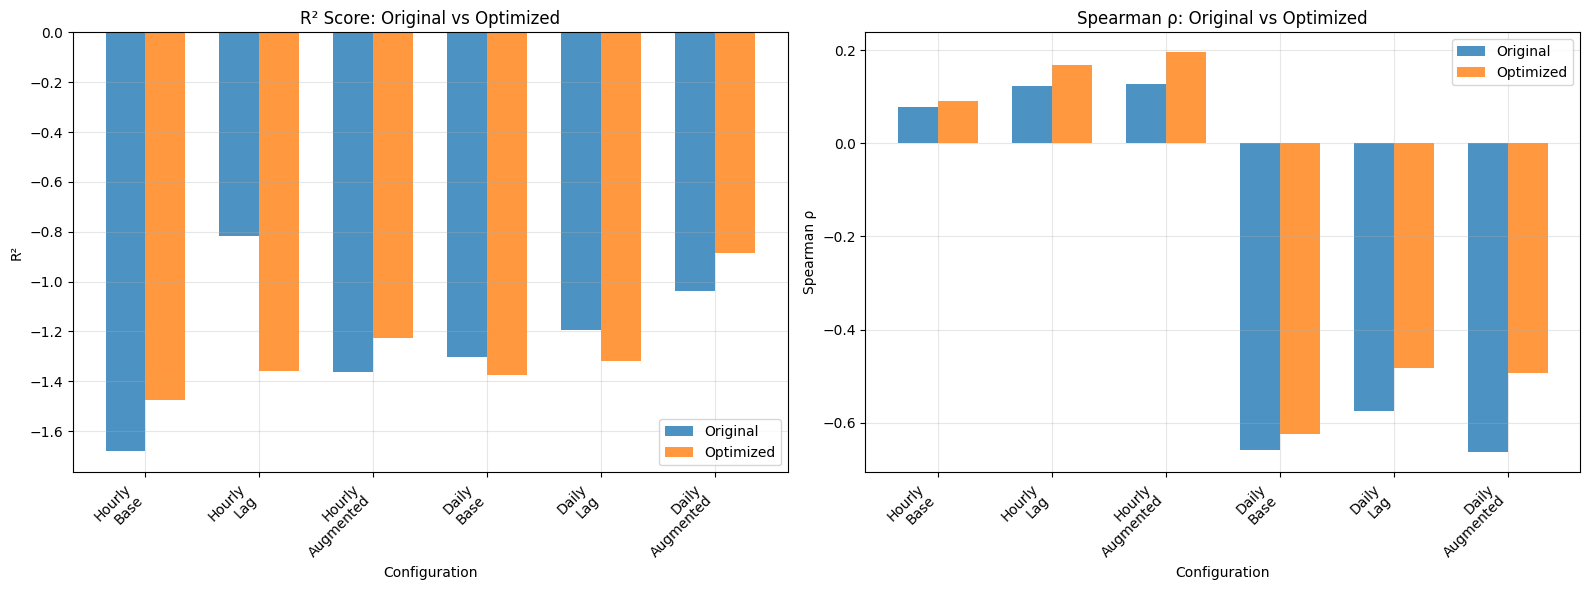

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save best parameters

In [223]:
# Define dataset name
dataset_name = "Aeschi"

# Create dataset subfolder inside existing xgboost_params folder
save_dir = os.path.join('xgboost_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to xgboost_params/Aeschi!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 30
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/xgboost_params/Aeschi

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +0.2057
Hourly          | Lag                  | ✓ ORIGINAL   | ΔR²: -0.5420
Hourly          | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.1379
Daily           | Base                 | ✓ ORIGINAL   | ΔR²: -0.0713
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -0.1240
Daily           | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.1532


# Experiment 4: Oensingen 2018-19 dataset

## Fix index and define predictors

In [224]:
# FIX TIMESTAMP
oensingen_1_lag['Timestamp'] = pd.to_datetime(oensingen_1_lag['Timestamp'])
oensingen_1_lag = oensingen_1_lag.set_index('Timestamp').sort_index()

oensingen_1_daily['Date'] = pd.to_datetime(oensingen_1_daily['Date'])
oensingen_1_daily = oensingen_1_daily.set_index('Date').sort_index()

In [225]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "SoilCultivation"
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

## Run finetuning


OPTIMIZING: Hourly | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2018-07-12 07:45:00 → 2019-09-14 08:45:00 (2808 samples, 90.0%)
Test:      2019-09-14 09:15:00 → 2019-10-02 02:15:00 (312 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.8536
Completed 20/500 iterations. Best CV R²: -0.8536
Completed 30/500 iterations. Best CV R²: -0.8382
Completed 40/500 iterations. Best CV R²: -0.8382
Completed 50/500 iterations. Best CV R²: -0.8382
Completed 60/500 iterations. Best CV R²: -0.8266
Completed 70/500 iterations. Best CV R²: -0.8266
Completed 80/500 iterations. Best CV R²: -0.8266
Completed 90/500 iterations. Best CV R²: -0.8266
Completed 100/500 iterations. Best CV R²: -0.8071
Completed 110/500 iterations. Best CV R²: -0.8071
Completed 120/500 iterations. Best CV R²: -0.8071
Completed 130/500 iterations. Best CV R²: -0.8071
Comple

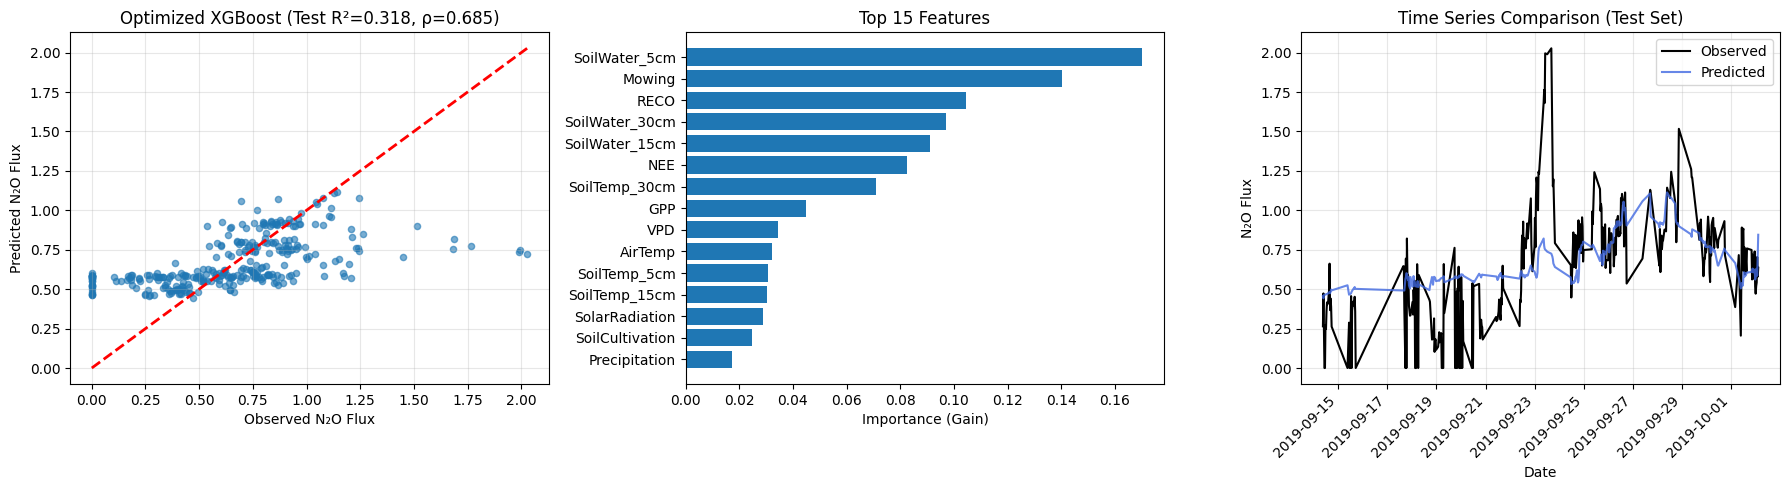


✓ Completed Hourly | Base
  Test R²: 0.3178
  Test ρ: 0.6853

OPTIMIZING: Hourly | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2018-07-19 06:45:00 → 2019-09-18 00:45:00 (2389 samples, 90.0%)
Test:      2019-09-18 01:15:00 → 2019-10-02 02:15:00 (266 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -1.4993
Completed 20/500 iterations. Best CV R²: -1.4993
Completed 30/500 iterations. Best CV R²: -1.4975
Completed 40/500 iterations. Best CV R²: -1.4531
Completed 50/500 iterations. Best CV R²: -1.4531
Completed 60/500 iterations. Best CV R²: -1.4531
Completed 70/500 iterations. Best CV R²: -1.4531
Completed 80/500 iterations. Best CV R²: -1.4531
Completed 90/500 iterations. Best CV R²: -1.4531
Completed 100/500 iterations. Best CV R²: -1.4531
Completed 110/500 iterations. Best CV R²: -1.4531
Completed 120/500 iterations. Best CV R²: -1.

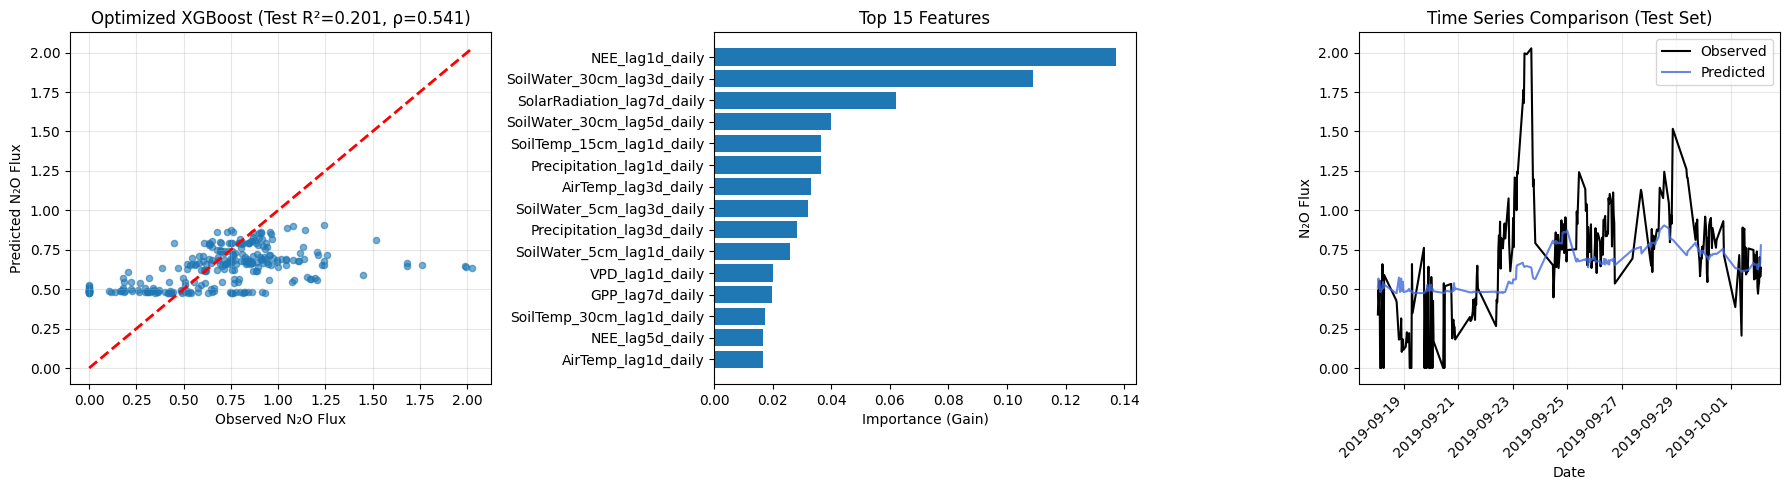


✓ Completed Hourly | Lag
  Test R²: 0.2009
  Test ρ: 0.5413

OPTIMIZING: Hourly | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2018-07-19 06:45:00 → 2019-09-18 00:45:00 (2389 samples, 90.0%)
Test:      2019-09-18 01:15:00 → 2019-10-02 02:15:00 (266 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -1.8983
Completed 20/500 iterations. Best CV R²: -1.8983
Completed 30/500 iterations. Best CV R²: -1.8983
Completed 40/500 iterations. Best CV R²: -1.8983
Completed 50/500 iterations. Best CV R²: -1.8682
Completed 60/500 iterations. Best CV R²: -1.8682
Completed 70/500 iterations. Best CV R²: -1.8682
Completed 80/500 iterations. Best CV R²: -1.8237
Completed 90/500 iterations. Best CV R²: -1.8237
Completed 100/500 iterations. Best CV R²: -1.8237
Completed 110/500 iterations. Best CV R²: -1.8237
Completed 120/500 iterations. Best CV R²

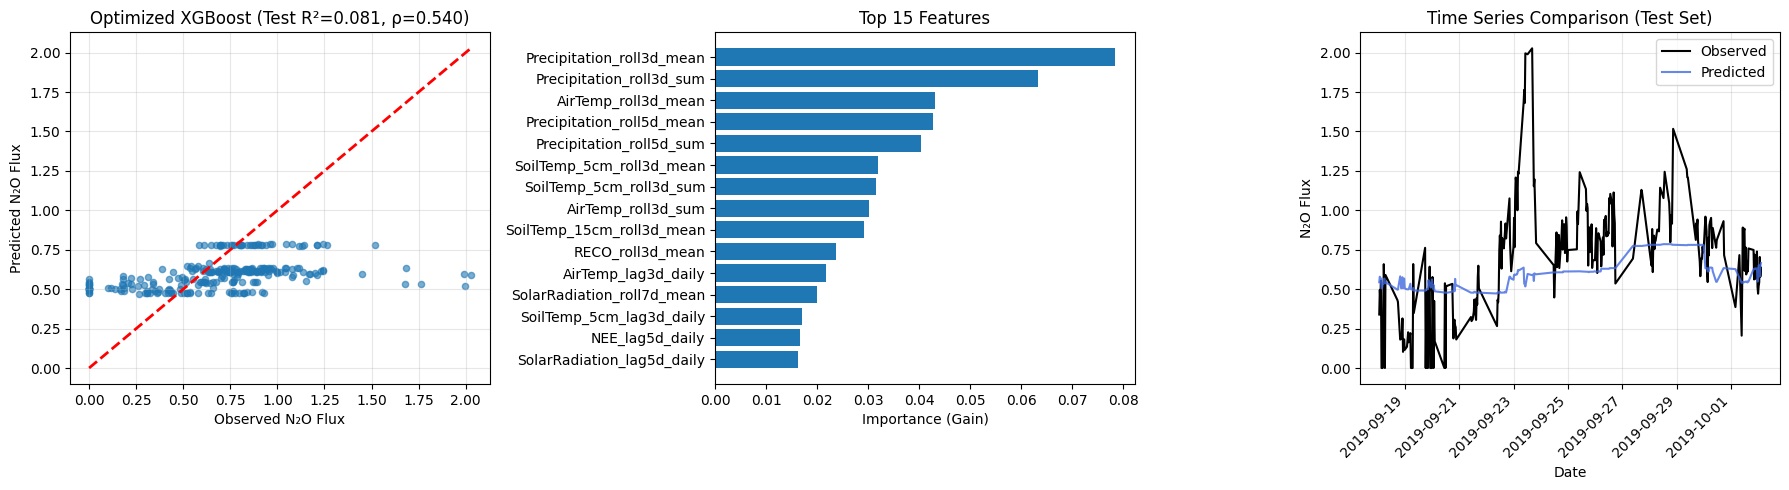


✓ Completed Hourly | Augmented
  Test R²: 0.0813
  Test ρ: 0.5403

OPTIMIZING: Daily | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2018-07-12 00:00:00 → 2019-09-15 00:00:00 (144 samples, 90.0%)
Test:      2019-09-17 00:00:00 → 2019-10-02 00:00:00 (16 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -3.0236
Completed 20/500 iterations. Best CV R²: -2.9075
Completed 30/500 iterations. Best CV R²: -2.8740
Completed 40/500 iterations. Best CV R²: -2.8740
Completed 50/500 iterations. Best CV R²: -2.8740
Completed 60/500 iterations. Best CV R²: -2.8740
Completed 70/500 iterations. Best CV R²: -2.8740
Completed 80/500 iterations. Best CV R²: -2.8740
Completed 90/500 iterations. Best CV R²: -2.8024
Completed 100/500 iterations. Best CV R²: -2.8024
Completed 110/500 iterations. Best CV R²: -2.8024
Completed 120/500 iterations. Best CV R²: 

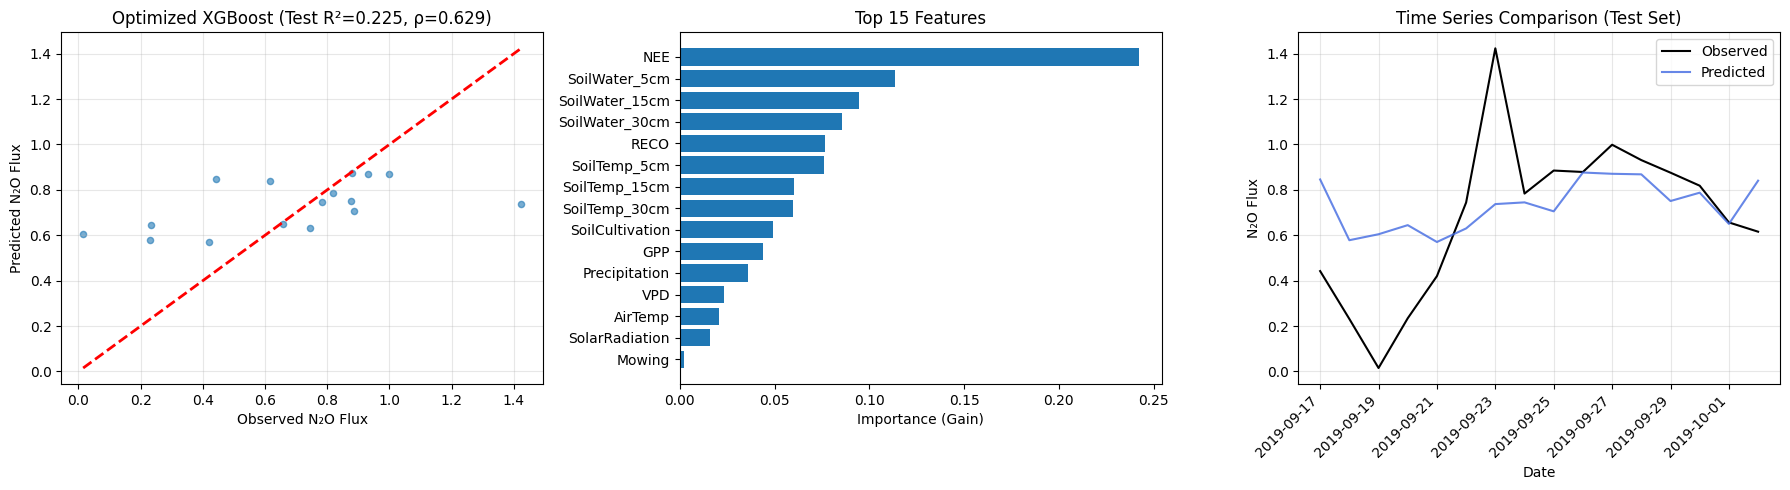


✓ Completed Daily | Base
  Test R²: 0.2254
  Test ρ: 0.6294

OPTIMIZING: Daily | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2018-07-19 00:00:00 → 2019-09-17 00:00:00 (131 samples, 89.7%)
Test:      2019-09-18 00:00:00 → 2019-10-02 00:00:00 (15 samples, 10.3%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -1.6463
Completed 20/500 iterations. Best CV R²: -1.4355
Completed 30/500 iterations. Best CV R²: -1.4355
Completed 40/500 iterations. Best CV R²: -1.4355
Completed 50/500 iterations. Best CV R²: -1.4355
Completed 60/500 iterations. Best CV R²: -1.4355
Completed 70/500 iterations. Best CV R²: -1.4138
Completed 80/500 iterations. Best CV R²: -1.4138
Completed 90/500 iterations. Best CV R²: -1.4138
Completed 100/500 iterations. Best CV R²: -1.4138
Completed 110/500 iterations. Best CV R²: -1.4138
Completed 120/500 iterations. Best CV R²: -1.4138

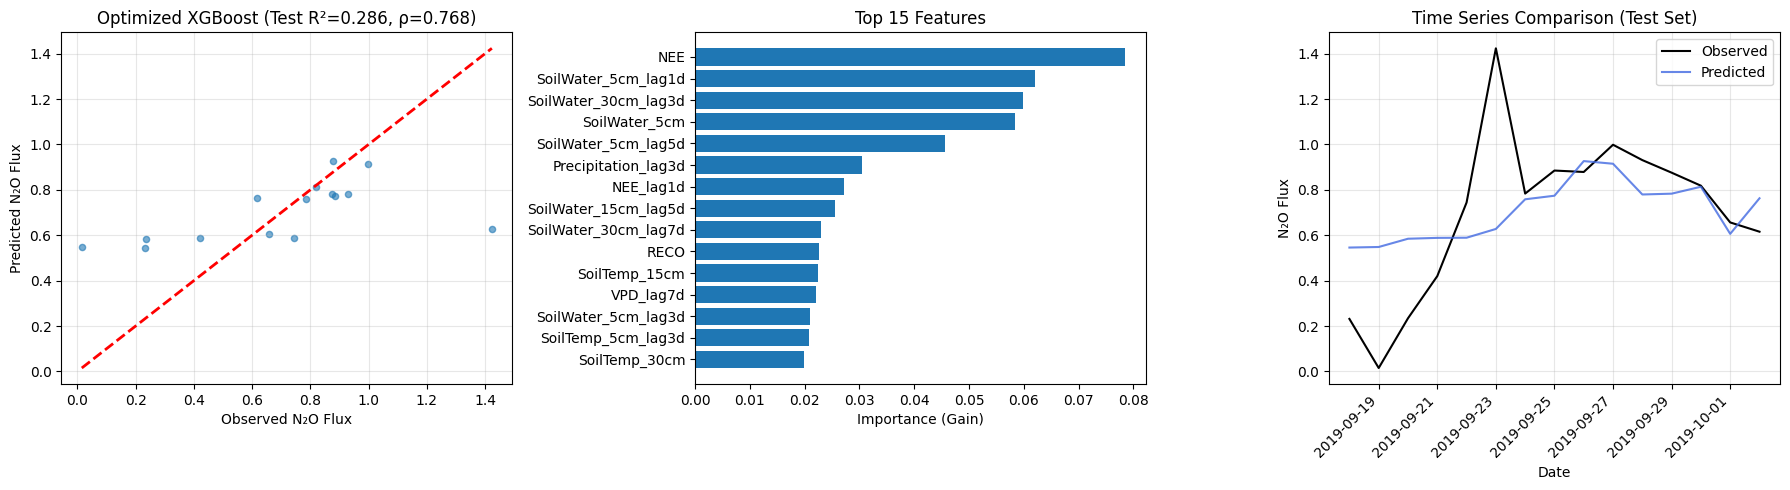


✓ Completed Daily | Lag
  Test R²: 0.2864
  Test ρ: 0.7679

OPTIMIZING: Daily | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2018-07-19 00:00:00 → 2019-09-17 00:00:00 (131 samples, 89.7%)
Test:      2019-09-18 00:00:00 → 2019-10-02 00:00:00 (15 samples, 10.3%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -1.0357
Completed 20/500 iterations. Best CV R²: -0.9574
Completed 30/500 iterations. Best CV R²: -0.9574
Completed 40/500 iterations. Best CV R²: -0.9574
Completed 50/500 iterations. Best CV R²: -0.9574
Completed 60/500 iterations. Best CV R²: -0.9574
Completed 70/500 iterations. Best CV R²: -0.9574
Completed 80/500 iterations. Best CV R²: -0.9574
Completed 90/500 iterations. Best CV R²: -0.9574
Completed 100/500 iterations. Best CV R²: -0.9574
Completed 110/500 iterations. Best CV R²: -0.9574
Completed 120/500 iterations. Best CV R²: -0

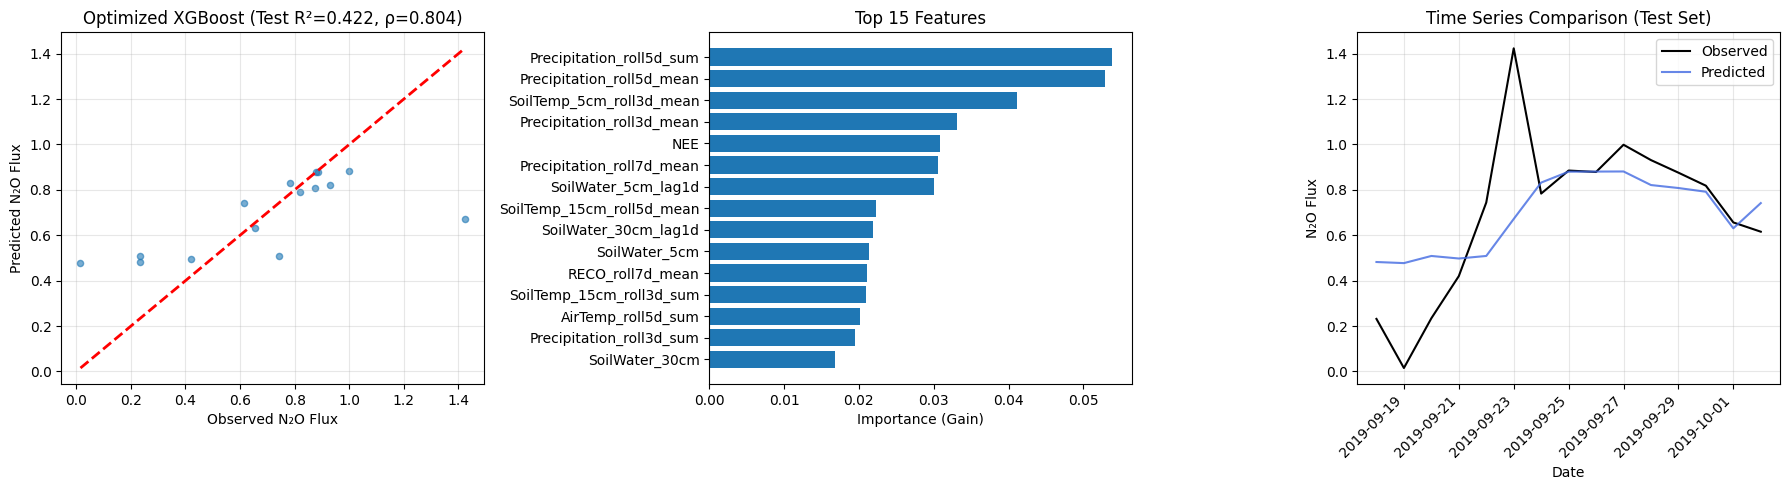


✓ Completed Daily | Augmented
  Test R²: 0.4218
  Test ρ: 0.8036


In [226]:
configurations = [
    ("Hourly", "Base", oensingen_1_lag, base_predictors),
    ("Hourly", "Lag", oensingen_1_lag, hourly_lag_predictors),
    ("Hourly", "Augmented", oensingen_1_lag, hourly_augmented_predictors),
    ("Daily", "Base", oensingen_1_daily, base_predictors),
    ("Daily", "Lag", oensingen_1_daily, daily_lag_predictors),
    ("Daily", "Augmented", oensingen_1_daily, daily_augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1,
        search_type='bayesian',
        n_iter=500,
        random_state=42,
        n_cv_splits=9
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        predictors=predictors,
        best_params=best_params,
        random_state=42,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

## Rerun original model for comparison

In [227]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_xgb_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        n_estimators=300,
        random_state=42,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2018-07-12 07:45:00 → 2019-09-09 01:45:00
Test  period: 2019-09-09 02:15:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.341
  Spearman ρ:        0.691

Running original Hourly | Lag...
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.218
  Spearman ρ:        0.544

Running original Hourly | Augmented...
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.092
  Spearman ρ:        0.551

Running original Daily | Base...
Train period: 2018-07-12 00:00:00 → 2019-09-12 00:00:00
Test  period: 2019-09-13 00:00:00 → 2019-10-0

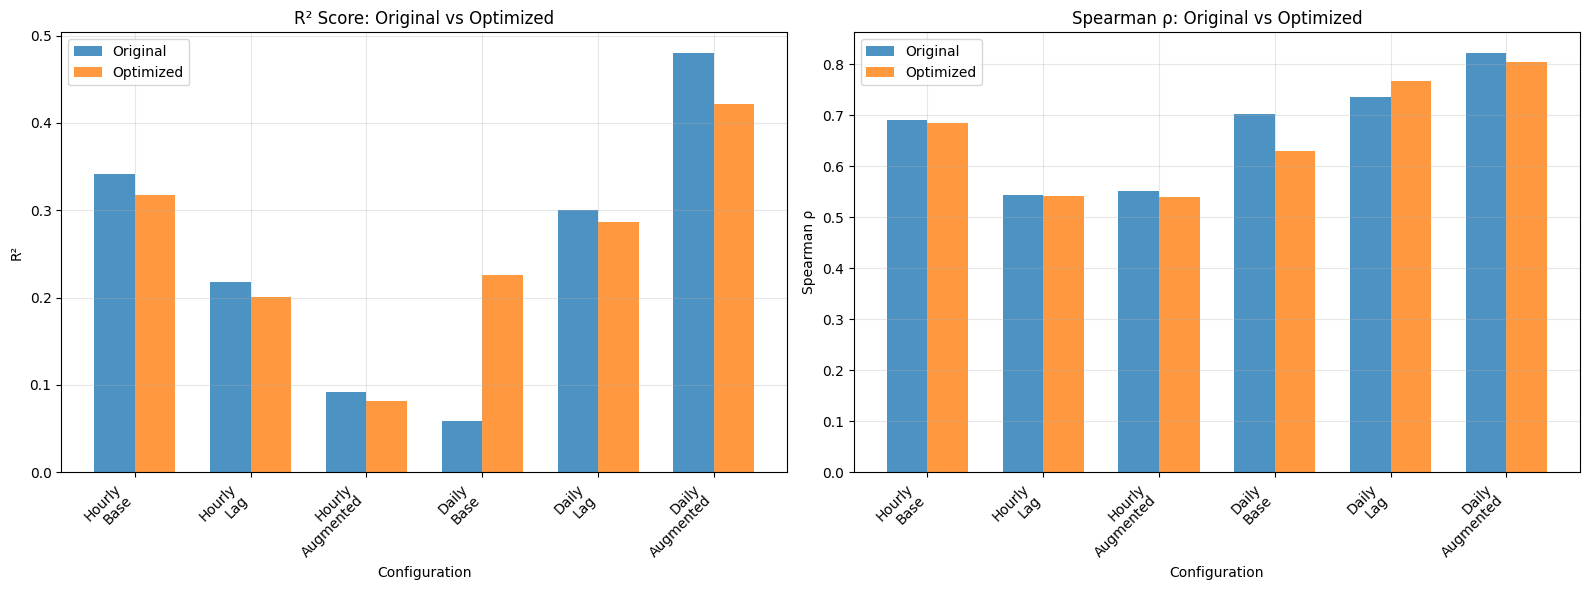

In [228]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save best parameters

In [229]:
# Define dataset name
dataset_name = "Oensingen_2018-19"

# Create dataset subfolder inside existing xgboost_params folder
save_dir = os.path.join('xgboost_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to xgboost_params/Oensingen_2018-19!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 30
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/xgboost_params/Oensingen_2018-19

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ ORIGINAL   | ΔR²: -0.0234
Hourly          | Lag                  | ✓ ORIGINAL   | ΔR²: -0.0169
Hourly          | Augmented            | ✓ ORIGINAL   | ΔR²: -0.0110
Daily           | Base                 | ✓ OPTIMIZED  | ΔR²: +0.1665
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -0.0136
Daily           | Augmented            | ✓ ORIGINAL   | ΔR²: -0.0578


# Experiment 5: Forel dataset

## Fix index and define predictors

In [8]:
# FIX TIMESTAMP
forel_lag['Timestamp'] = pd.to_datetime(forel_lag['Timestamp'])
forel_lag = forel_lag.set_index('Timestamp').sort_index()

forel_daily['Date'] = pd.to_datetime(forel_daily['Date'])
forel_daily = forel_daily.set_index('Date').sort_index()

In [9]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Fertilizer_N_kg_ha"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", 

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

## Run finetuning


OPTIMIZING: Hourly | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2024-03-14 11:15:00 → 2025-03-14 06:45:00 (5827 samples, 90.0%)
Test:      2025-03-14 07:15:00 → 2025-04-28 16:15:00 (648 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.7250
Completed 20/500 iterations. Best CV R²: -0.7250
Completed 30/500 iterations. Best CV R²: -0.7250
Completed 40/500 iterations. Best CV R²: -0.7071
Completed 50/500 iterations. Best CV R²: -0.7071
Completed 60/500 iterations. Best CV R²: -0.7071
Completed 70/500 iterations. Best CV R²: -0.7071
Completed 80/500 iterations. Best CV R²: -0.7071
Completed 90/500 iterations. Best CV R²: -0.7071
Completed 100/500 iterations. Best CV R²: -0.7071
Completed 110/500 iterations. Best CV R²: -0.7071
Completed 120/500 iterations. Best CV R²: -0.7071
Completed 130/500 iterations. Best CV R²: -0.7071
Comple

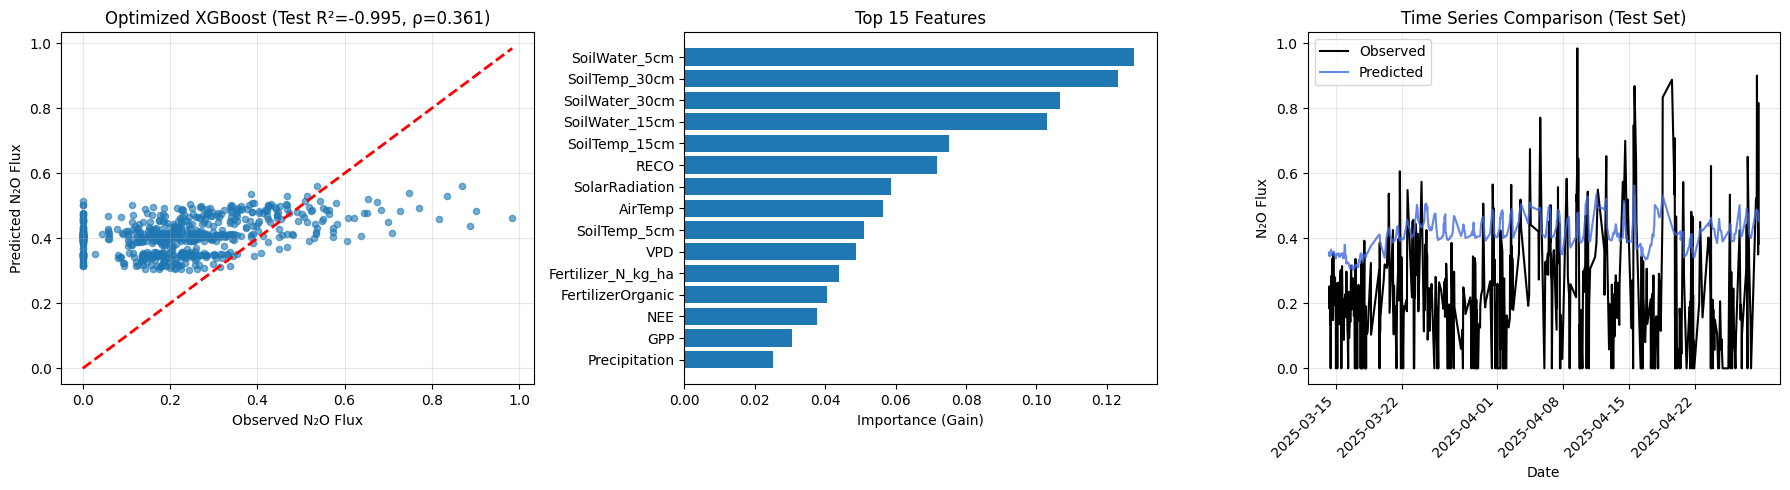


✓ Completed Hourly | Base
  Test R²: -0.9949
  Test ρ: 0.3605

OPTIMIZING: Hourly | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2024-03-21 04:45:00 → 2025-03-14 13:45:00 (5723 samples, 90.0%)
Test:      2025-03-14 14:45:00 → 2025-04-28 16:15:00 (636 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.3854
Completed 20/500 iterations. Best CV R²: -0.3854
Completed 30/500 iterations. Best CV R²: -0.3517
Completed 40/500 iterations. Best CV R²: -0.3517
Completed 50/500 iterations. Best CV R²: -0.3517
Completed 60/500 iterations. Best CV R²: -0.3388
Completed 70/500 iterations. Best CV R²: -0.3388
Completed 80/500 iterations. Best CV R²: -0.3388
Completed 90/500 iterations. Best CV R²: -0.3388
Completed 100/500 iterations. Best CV R²: -0.3388
Completed 110/500 iterations. Best CV R²: -0.3262
Completed 120/500 iterations. Best CV R²: -0

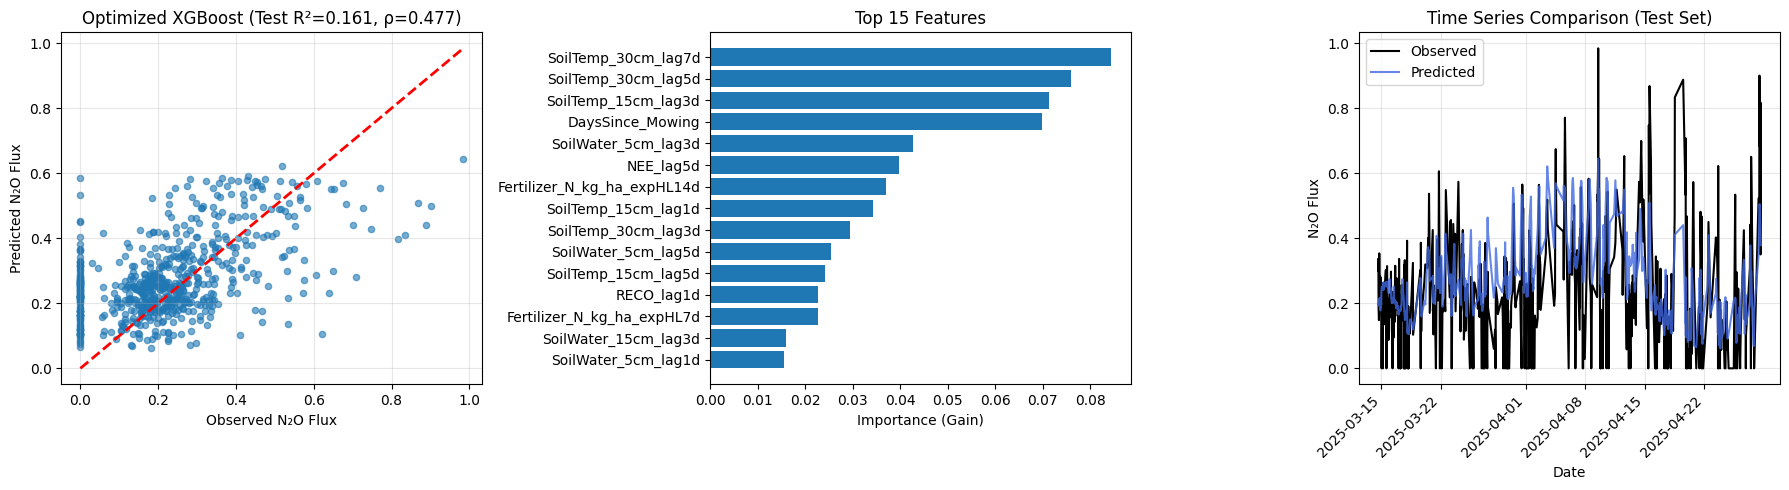


✓ Completed Hourly | Lag
  Test R²: 0.1614
  Test ρ: 0.4767

OPTIMIZING: Hourly | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2024-03-21 04:45:00 → 2025-03-14 13:45:00 (5723 samples, 90.0%)
Test:      2025-03-14 14:45:00 → 2025-04-28 16:15:00 (636 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.4353
Completed 20/500 iterations. Best CV R²: -0.3649
Completed 30/500 iterations. Best CV R²: -0.3649
Completed 40/500 iterations. Best CV R²: -0.3303
Completed 50/500 iterations. Best CV R²: -0.3303
Completed 60/500 iterations. Best CV R²: -0.3303
Completed 70/500 iterations. Best CV R²: -0.3303
Completed 80/500 iterations. Best CV R²: -0.3303
Completed 90/500 iterations. Best CV R²: -0.3256
Completed 100/500 iterations. Best CV R²: -0.3255
Completed 110/500 iterations. Best CV R²: -0.3255
Completed 120/500 iterations. Best CV R²

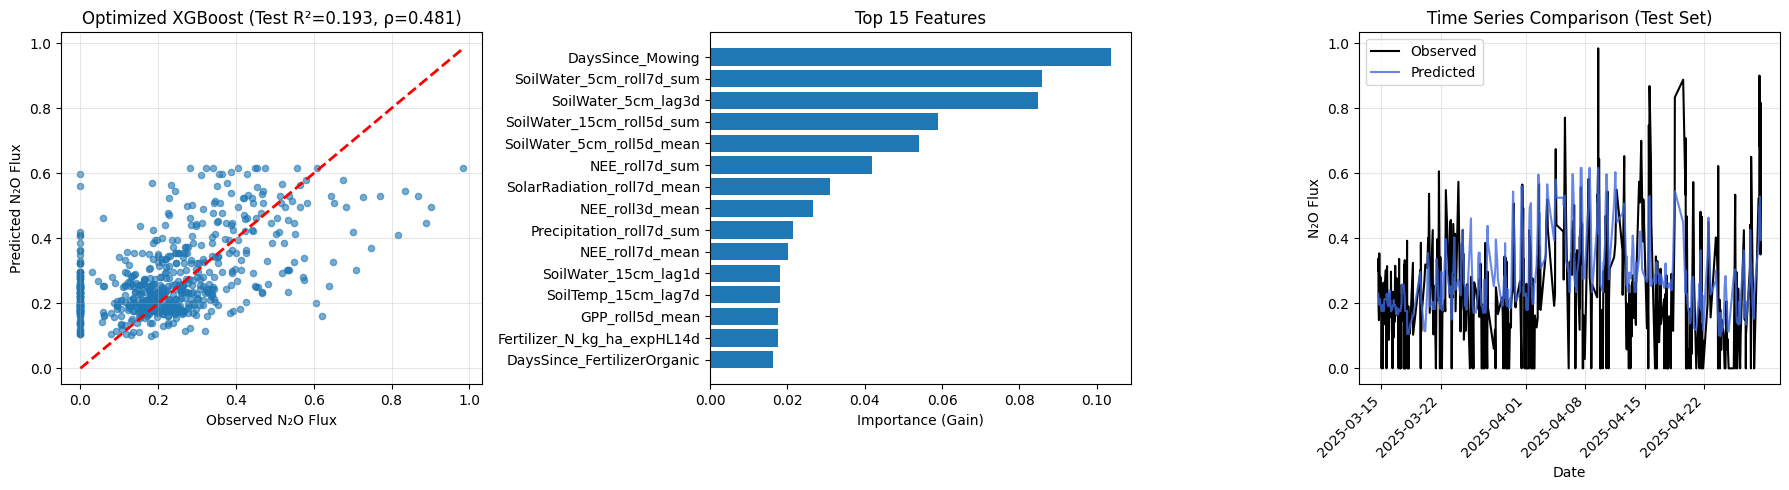


✓ Completed Hourly | Augmented
  Test R²: 0.1925
  Test ρ: 0.4811

OPTIMIZING: Daily | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2024-03-14 00:00:00 → 2025-03-18 00:00:00 (361 samples, 89.8%)
Test:      2025-03-19 00:00:00 → 2025-04-28 00:00:00 (41 samples, 10.2%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 10/500 iterations. Best CV R²: -0.4006
Completed 20/500 iterations. Best CV R²: -0.3761
Completed 30/500 iterations. Best CV R²: -0.3761
Completed 40/500 iterations. Best CV R²: -0.3284
Completed 50/500 iterations. Best CV R²: -0.3127


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 60/500 iterations. Best CV R²: -0.3127
Completed 70/500 iterations. Best CV R²: -0.3127
Completed 80/500 iterations. Best CV R²: -0.3127


...

Completed 230/500 iterations. Best CV R²: -0.2714
Completed 240/500 iterations. Best CV R²: -0.2714
Completed 250/500 iterations. Best CV R²: -0.2714
Completed 260/500 iterations. Best CV R²: -0.2714
Completed 270/500 iterations. Best CV R²: -0.2714
Completed 280/500 iterations. Best CV R²: -0.2714
Completed 290/500 iterations. Best CV R²: -0.2714
Completed 300/500 iterations. Best CV R²: -0.2714
Completed 310/500 iterations. Best CV R²: -0.2714
Completed 320/500 iterations. Best CV R²: -0.2714
Completed 330/500 iterations. Best CV R²: -0.2714
Completed 340/500 iterations. Best CV R²: -0.2714
Completed 350/500 iterations. Best CV R²: -0.2714


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 360/500 iterations. Best CV R²: -0.2714
Completed 370/500 iterations. Best CV R²: -0.2714
Completed 380/500 iterations. Best CV R²: -0.2714


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 390/500 iterations. Best CV R²: -0.2714
Completed 400/500 iterations. Best CV R²: -0.2714
Completed 410/500 iterations. Best CV R²: -0.2714
Completed 420/500 iterations. Best CV R²: -0.2714
Completed 430/500 iterations. Best CV R²: -0.2714
Completed 440/500 iterations. Best CV R²: -0.2714
Completed 450/500 iterations. Best CV R²: -0.2714
Completed 460/500 iterations. Best CV R²: -0.2714
Completed 470/500 iterations. Best CV R²: -0.2714
Completed 480/500 iterations. Best CV R²: -0.2714
Completed 490/500 iterations. Best CV R²: -0.2714
Completed 500/500 iterations. Best CV R²: -0.2714

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.6
  gamma: 0.2
  learning_rate: 0.1
  max_depth: 3
  min_child_weight: 5
  n_estimators: 100
  subsample: 0.6

Best CV R² (mean across 9 folds): -0.2714

Training final model on 361 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -0.663

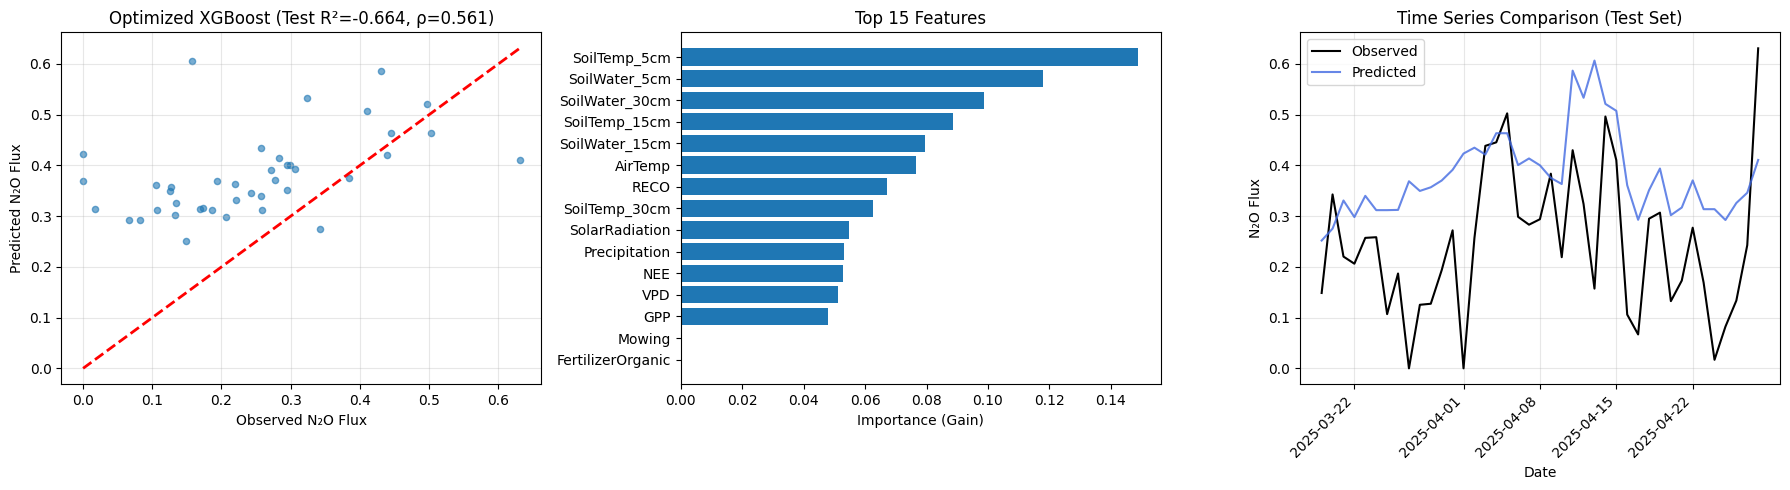


✓ Completed Daily | Base
  Test R²: -0.6636
  Test ρ: 0.5610

OPTIMIZING: Daily | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2024-03-21 00:00:00 → 2025-03-19 00:00:00 (355 samples, 89.9%)
Test:      2025-03-20 00:00:00 → 2025-04-28 00:00:00 (40 samples, 10.1%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 10/500 iterations. Best CV R²: -1.0018


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 20/500 iterations. Best CV R²: -1.0018


...

Completed 480/500 iterations. Best CV R²: -0.7244


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 490/500 iterations. Best CV R²: -0.7244


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 500/500 iterations. Best CV R²: -0.7244

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.6
  gamma: 0
  learning_rate: 0.2
  max_depth: 3
  min_child_weight: 5
  n_estimators: 500
  subsample: 0.8

Best CV R² (mean across 9 folds): -0.7244

Training final model on 355 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -0.2490
Spearman ρ:        0.6463


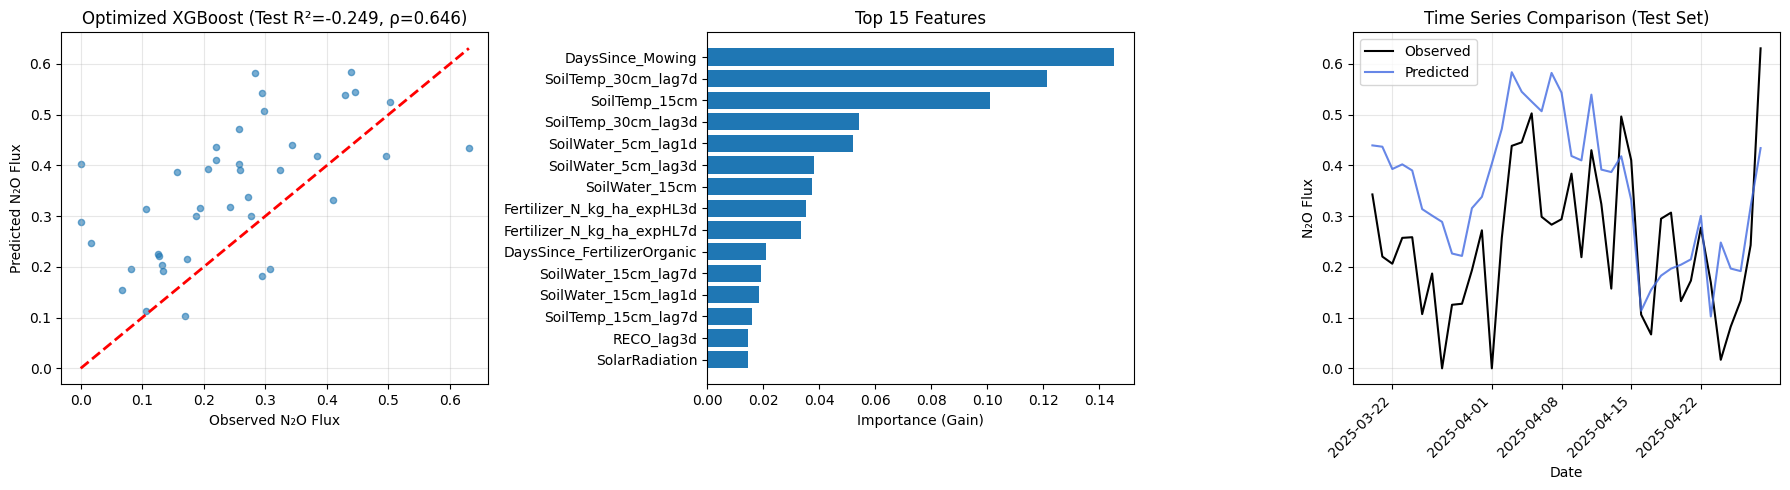


✓ Completed Daily | Lag
  Test R²: -0.2490
  Test ρ: 0.6463

OPTIMIZING: Daily | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2024-03-21 00:00:00 → 2025-03-19 00:00:00 (355 samples, 89.9%)
Test:      2025-03-20 00:00:00 → 2025-04-28 00:00:00 (40 samples, 10.1%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 10/500 iterations. Best CV R²: -0.8555


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 20/500 iterations. Best CV R²: -0.8555


...

Completed 480/500 iterations. Best CV R²: -0.7696


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 490/500 iterations. Best CV R²: -0.7696


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 500/500 iterations. Best CV R²: -0.7696

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.8
  gamma: 0
  learning_rate: 0.1
  max_depth: 3
  min_child_weight: 3
  n_estimators: 300
  subsample: 0.8

Best CV R² (mean across 9 folds): -0.7696

Training final model on 355 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -0.6239
Spearman ρ:        0.4778


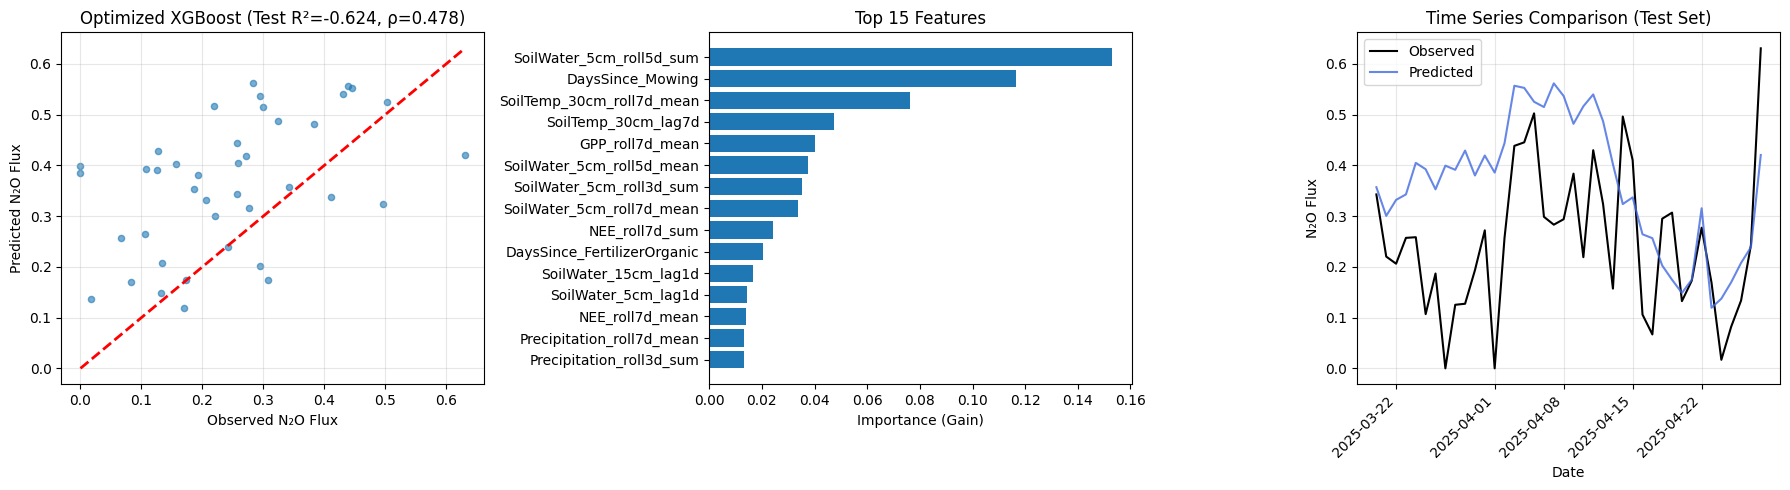


✓ Completed Daily | Augmented
  Test R²: -0.6239
  Test ρ: 0.4778


In [10]:
configurations = [
    ("Hourly", "Base", forel_lag, base_predictors),
    ("Hourly", "Lag", forel_lag, lag_predictors),
    ("Hourly", "Augmented", forel_lag, augmented_predictors),
    ("Daily", "Base", forel_daily, base_predictors),
    ("Daily", "Lag", forel_daily, lag_predictors),
    ("Daily", "Augmented", forel_daily, augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1,
        search_type='bayesian',
        n_iter=500,
        random_state=42,
        n_cv_splits=9
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        predictors=predictors,
        best_params=best_params,
        random_state=42,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

## Rerun original model for comparison

In [11]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_xgb_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        n_estimators=300,
        random_state=42,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2024-03-07 21:15:00 → 2025-03-01 19:15:00
Test  period: 2025-03-01 19:45:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): -1.049
  Spearman ρ:        0.329

Running original Hourly | Lag...
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.124
  Spearman ρ:        0.466

Running original Hourly | Augmented...
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): 0.133
  Spearman ρ:        0.452

Running original Daily | Base...
Train period: 2024-03-07 00:00:00 → 2025-03-11 00:00:00
Test  period: 2025-03-12 00:00:00 → 2025-05-

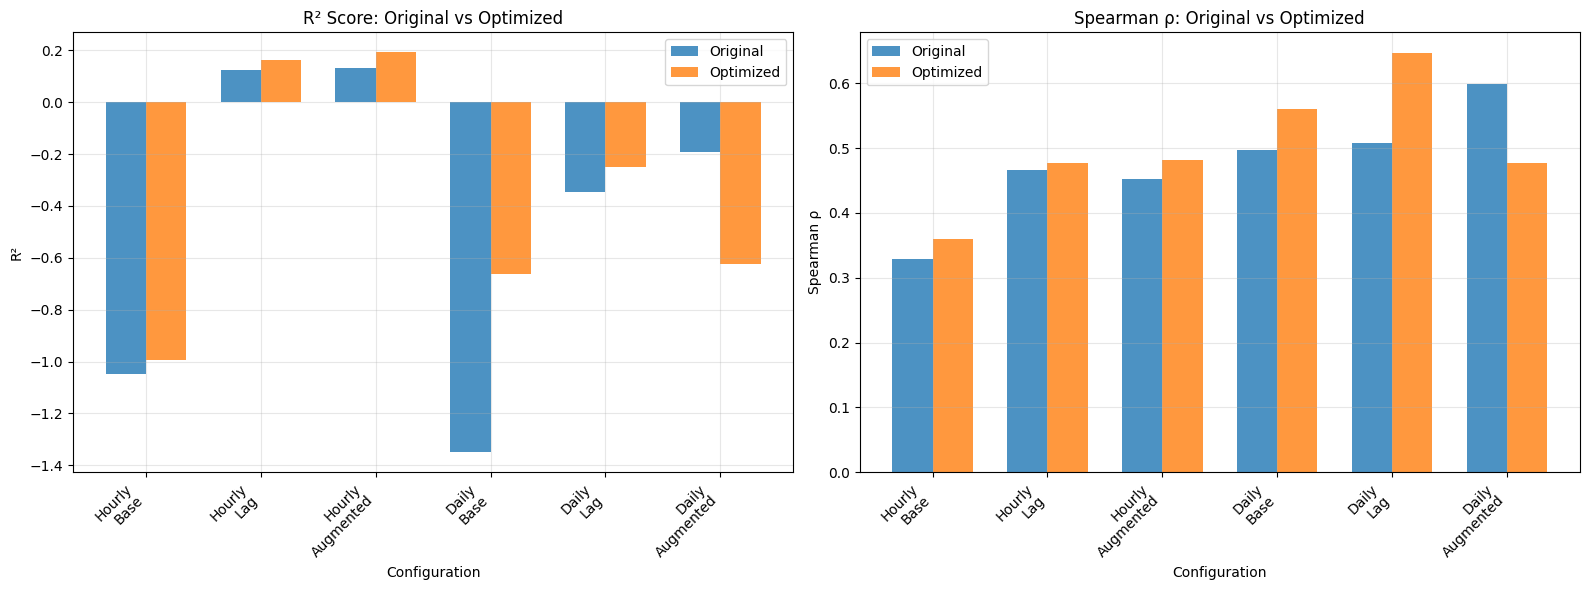

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save best parameters

In [13]:
# Define dataset name
dataset_name = "Forel"

# Create dataset subfolder inside existing xgboost_params folder
save_dir = os.path.join('xgboost_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to xgboost_params/Forel!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 30
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/xgboost_params/Forel

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +0.0537
Hourly          | Lag                  | ✓ OPTIMIZED  | ΔR²: +0.0370
Hourly          | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.0597
Daily           | Base                 | ✓ OPTIMIZED  | ΔR²: +0.6864
Daily           | Lag                  | ✓ OPTIMIZED  | ΔR²: +0.0955
Daily           | Augmented            | ✓ ORIGINAL   | ΔR²: -0.4333


# Experiment 6: Tanikon dataset

## Fix index and define predictors

In [14]:
# FIX TIMESTAMP
tanikon_lag['Timestamp'] = pd.to_datetime(tanikon_lag['Timestamp'])
tanikon_lag = tanikon_lag.set_index('Timestamp').sort_index()

tanikon_daily['Date'] = pd.to_datetime(tanikon_daily['Date'])
tanikon_daily = tanikon_daily.set_index('Date').sort_index()

In [15]:
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

## Run finetuning


OPTIMIZING: Hourly | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2023-12-04 16:15:00 → 2025-04-13 09:15:00 (18632 samples, 90.0%)
Test:      2025-04-13 09:45:00 → 2025-06-03 21:45:00 (2071 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.4355
Completed 20/500 iterations. Best CV R²: -0.4355
Completed 30/500 iterations. Best CV R²: -0.4355
Completed 40/500 iterations. Best CV R²: -0.4355
Completed 50/500 iterations. Best CV R²: -0.4355
Completed 60/500 iterations. Best CV R²: -0.4355
Completed 70/500 iterations. Best CV R²: -0.4355
Completed 80/500 iterations. Best CV R²: -0.4355
Completed 90/500 iterations. Best CV R²: -0.4355
Completed 100/500 iterations. Best CV R²: -0.4335
Completed 110/500 iterations. Best CV R²: -0.4335
Completed 120/500 iterations. Best CV R²: -0.4279
Completed 130/500 iterations. Best CV R²: -0.4279
Comp

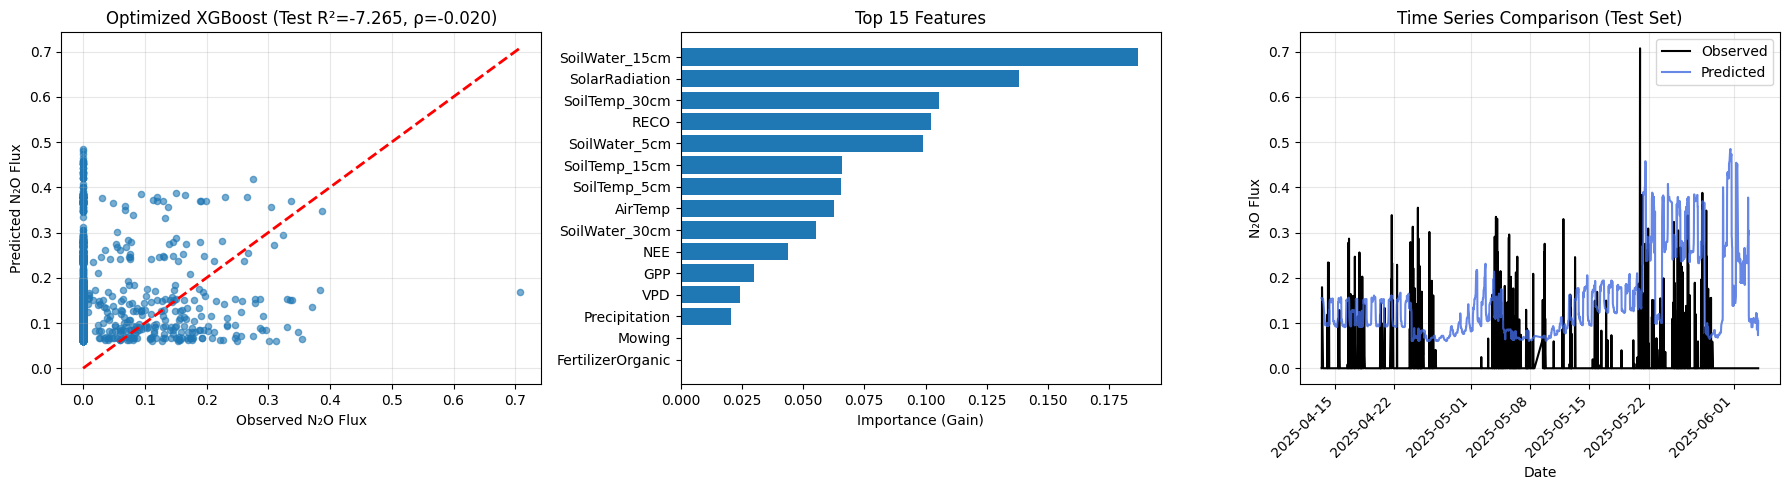


✓ Completed Hourly | Base
  Test R²: -7.2648
  Test ρ: -0.0201

OPTIMIZING: Hourly | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2023-12-11 00:15:00 → 2025-04-15 10:45:00 (17897 samples, 90.0%)
Test:      2025-04-15 11:15:00 → 2025-06-03 21:45:00 (1989 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.8501
Completed 20/500 iterations. Best CV R²: -0.8501
Completed 30/500 iterations. Best CV R²: -0.8022
Completed 40/500 iterations. Best CV R²: -0.8022
Completed 50/500 iterations. Best CV R²: -0.8022
Completed 60/500 iterations. Best CV R²: -0.8022
Completed 70/500 iterations. Best CV R²: -0.8022
Completed 80/500 iterations. Best CV R²: -0.6867
Completed 90/500 iterations. Best CV R²: -0.6867
Completed 100/500 iterations. Best CV R²: -0.6867
Completed 110/500 iterations. Best CV R²: -0.6867
Completed 120/500 iterations. Best CV R²:

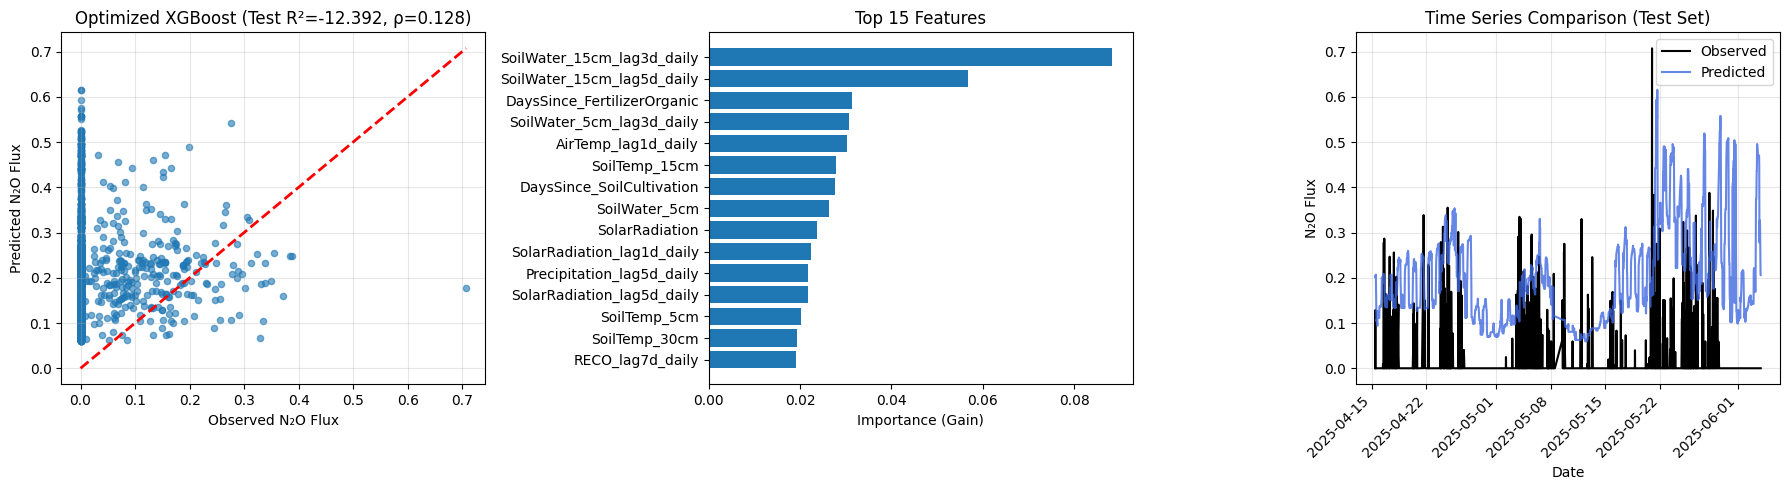


✓ Completed Hourly | Lag
  Test R²: -12.3921
  Test ρ: 0.1284

OPTIMIZING: Hourly | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2023-12-11 00:15:00 → 2025-04-15 10:45:00 (17897 samples, 90.0%)
Test:      2025-04-15 11:15:00 → 2025-06-03 21:45:00 (1989 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data
Completed 10/500 iterations. Best CV R²: -0.8387
Completed 20/500 iterations. Best CV R²: -0.8387
Completed 30/500 iterations. Best CV R²: -0.8053
Completed 40/500 iterations. Best CV R²: -0.7596
Completed 50/500 iterations. Best CV R²: -0.7196
Completed 60/500 iterations. Best CV R²: -0.7196
Completed 70/500 iterations. Best CV R²: -0.7196
Completed 80/500 iterations. Best CV R²: -0.7029
Completed 90/500 iterations. Best CV R²: -0.7029
Completed 100/500 iterations. Best CV R²: -0.7029
Completed 110/500 iterations. Best CV R²: -0.7029
Completed 120/500 iterations. Best C

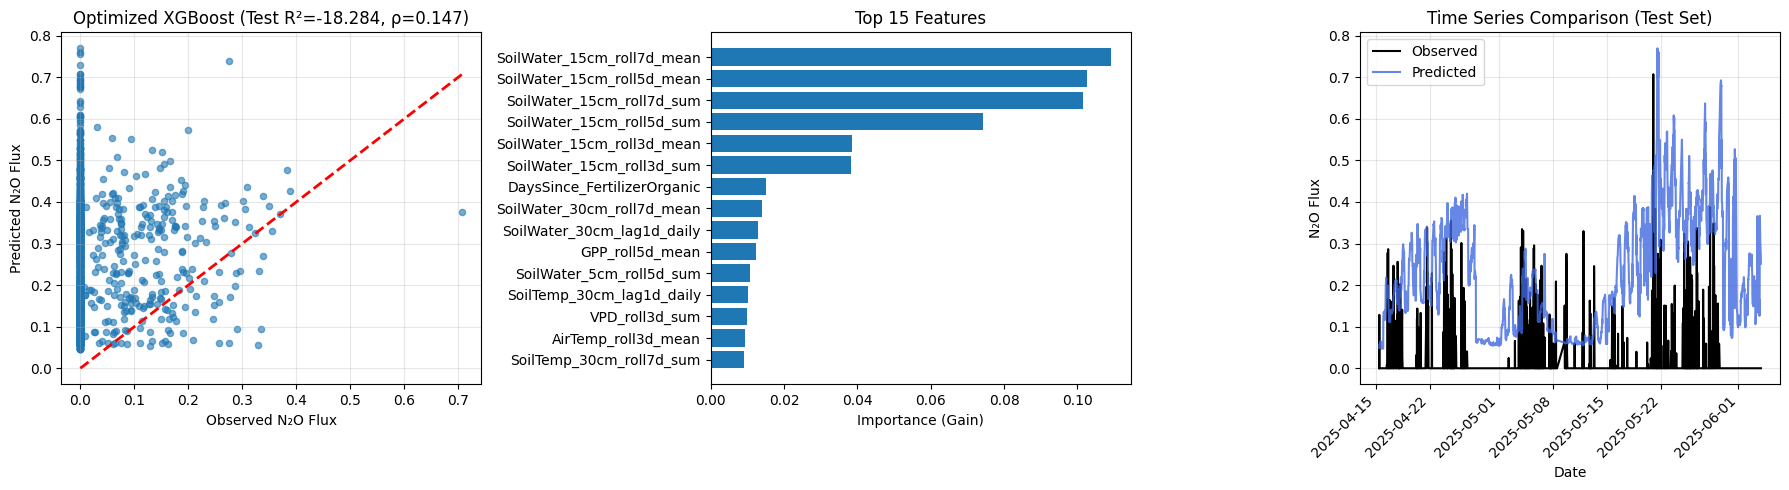


✓ Completed Hourly | Augmented
  Test R²: -18.2842
  Test ρ: 0.1470

OPTIMIZING: Daily | Base
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2023-12-05 00:00:00 → 2025-04-10 00:00:00 (718 samples, 90.0%)
Test:      2025-04-11 00:00:00 → 2025-05-29 00:00:00 (80 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -1.2329


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -1.2190


...

Completed 480/500 iterations. Best CV R²: -0.9079


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -0.9079


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -0.9079

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.8
  gamma: 0.5
  learning_rate: 0.2
  max_depth: 4
  min_child_weight: 5
  n_estimators: 100
  subsample: 0.6

Best CV R² (mean across 9 folds): -0.9079

Training final model on 718 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -48.6814
Spearman ρ:        -0.0592


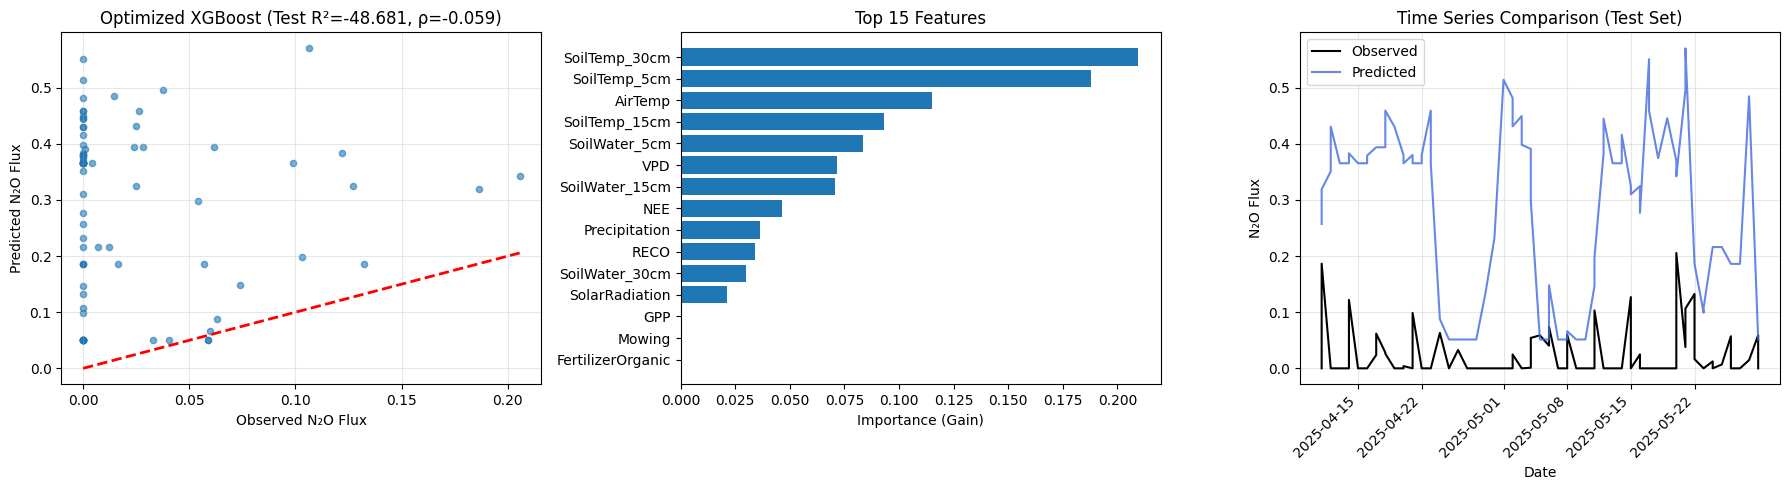


✓ Completed Daily | Base
  Test R²: -48.6814
  Test ρ: -0.0592

OPTIMIZING: Daily | Lag
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2023-12-11 00:00:00 → 2025-04-12 00:00:00 (692 samples, 90.0%)
Test:      2025-04-12 00:00:00 → 2025-05-29 00:00:00 (77 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -0.8436


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -0.8436


...

Completed 480/500 iterations. Best CV R²: -0.7034


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -0.7034


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -0.7034

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.7
  gamma: 0.2
  learning_rate: 0.2
  max_depth: 4
  min_child_weight: 3
  n_estimators: 100
  subsample: 0.9

Best CV R² (mean across 9 folds): -0.7034

Training final model on 692 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -121.4718
Spearman ρ:        0.2236


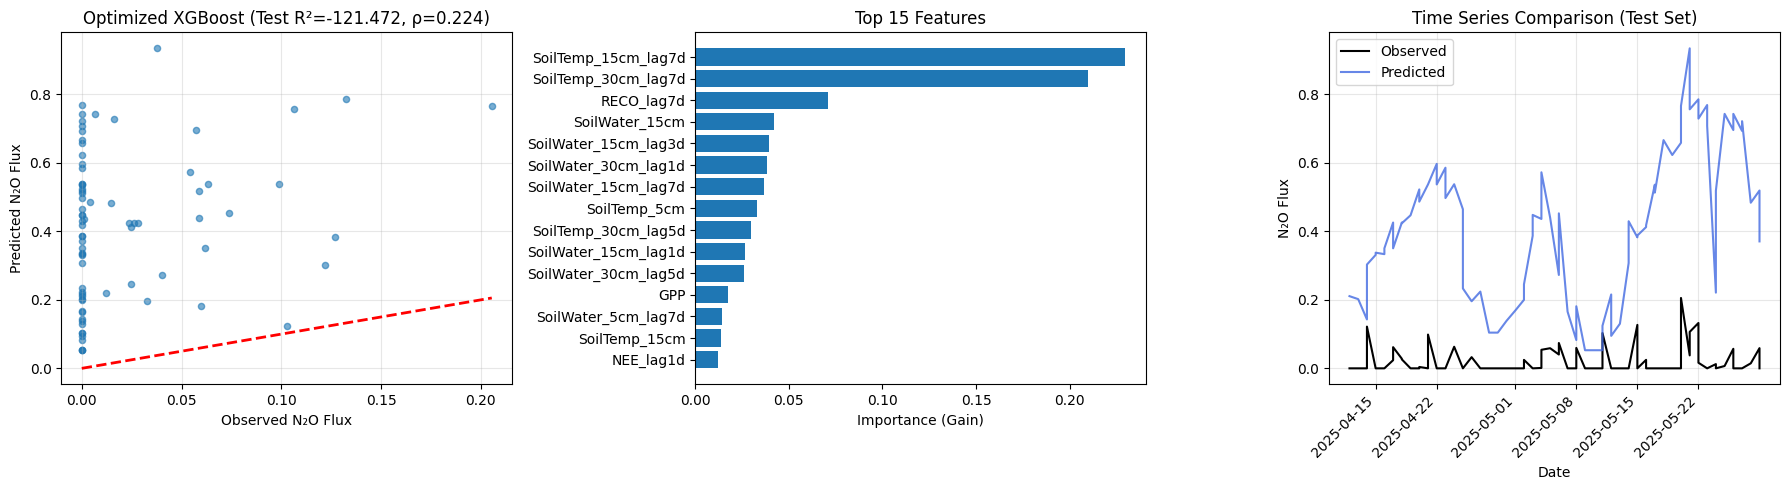


✓ Completed Daily | Lag
  Test R²: -121.4718
  Test ρ: 0.2236

OPTIMIZING: Daily | Augmented
Starting hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 9

Train+Val: 2023-12-11 00:00:00 → 2025-04-12 00:00:00 (692 samples, 90.0%)
Test:      2025-04-12 00:00:00 → 2025-05-29 00:00:00 (77 samples, 10.0%)

⚠️  Using 9-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 10/500 iterations. Best CV R²: -1.2184


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 20/500 iterations. Best CV R²: -1.0476


...

Completed 480/500 iterations. Best CV R²: -0.9278


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 490/500 iterations. Best CV R²: -0.9278


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_63394/3555769120.py:22: ConstantInputWarning: An input ar

Completed 500/500 iterations. Best CV R²: -0.9278

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  colsample_bytree: 0.6
  gamma: 0.5
  learning_rate: 0.01
  max_depth: 5
  min_child_weight: 5
  n_estimators: 300
  subsample: 0.8

Best CV R² (mean across 9 folds): -0.9278

Training final model on 692 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS NORMAL MODEL)
R² (linear scale): -212.4023
Spearman ρ:        0.2014


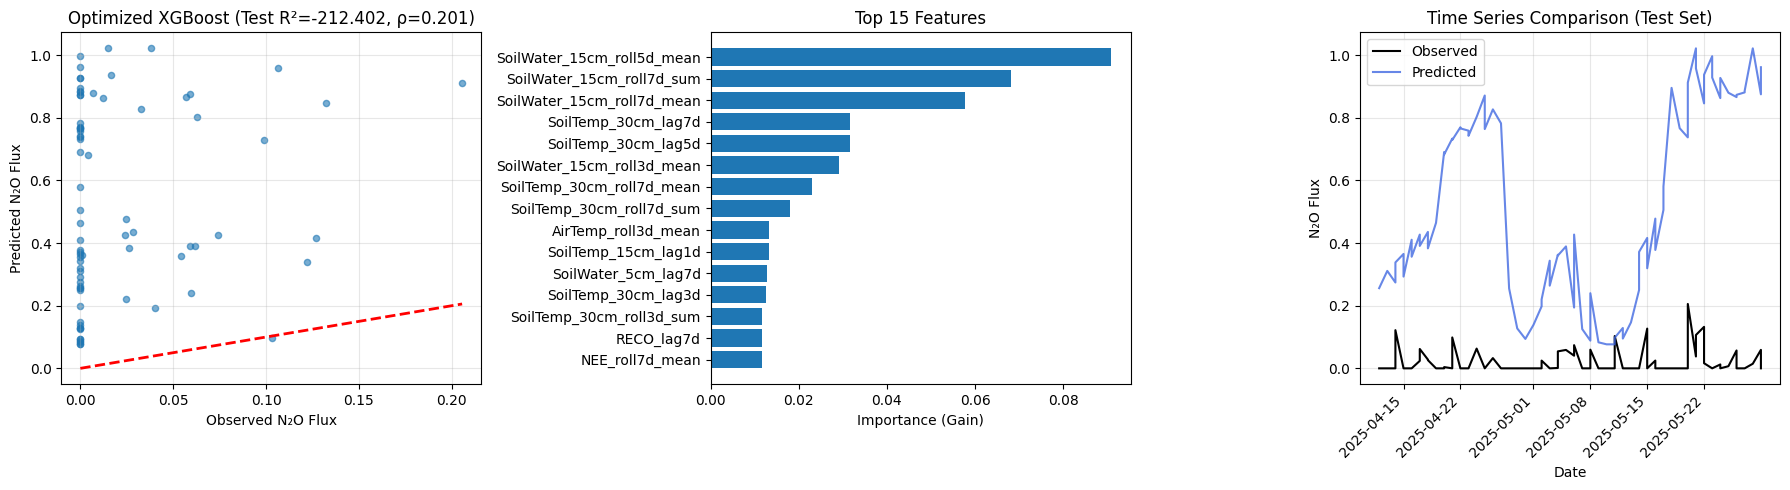


✓ Completed Daily | Augmented
  Test R²: -212.4023
  Test ρ: 0.2014


In [16]:
configurations = [
    ("Hourly", "Base", tanikon_lag, base_predictors),
    ("Hourly", "Lag", tanikon_lag, hourly_lag_predictors),
    ("Hourly", "Augmented", tanikon_lag, hourly_augmented_predictors),
    ("Daily", "Base", tanikon_daily, base_predictors),
    ("Daily", "Lag", tanikon_daily, daily_lag_predictors),
    ("Daily", "Augmented", tanikon_daily, daily_augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1,
        search_type='bayesian',
        n_iter=500,
        random_state=42,
        n_cv_splits=9
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        predictors=predictors,
        best_params=best_params,
        random_state=42,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

## Rerun original model for comparison

In [17]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_xgb_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        n_estimators=300,
        random_state=42,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2023-11-07 15:45:00 → 2025-02-17 03:45:00
Test  period: 2025-02-17 04:15:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): -65.989
  Spearman ρ:        0.054

Running original Hourly | Lag...
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): -35.941
  Spearman ρ:        0.139

Running original Hourly | Augmented...
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Model evaluation:
  R² (linear scale): -56.267
  Spearman ρ:        0.173

Running original Daily | Base...
Train period: 2023-11-07 00:00:00 → 2025-02-16 00:00:00
Test  period: 2025-02-17 00:00:00 → 202

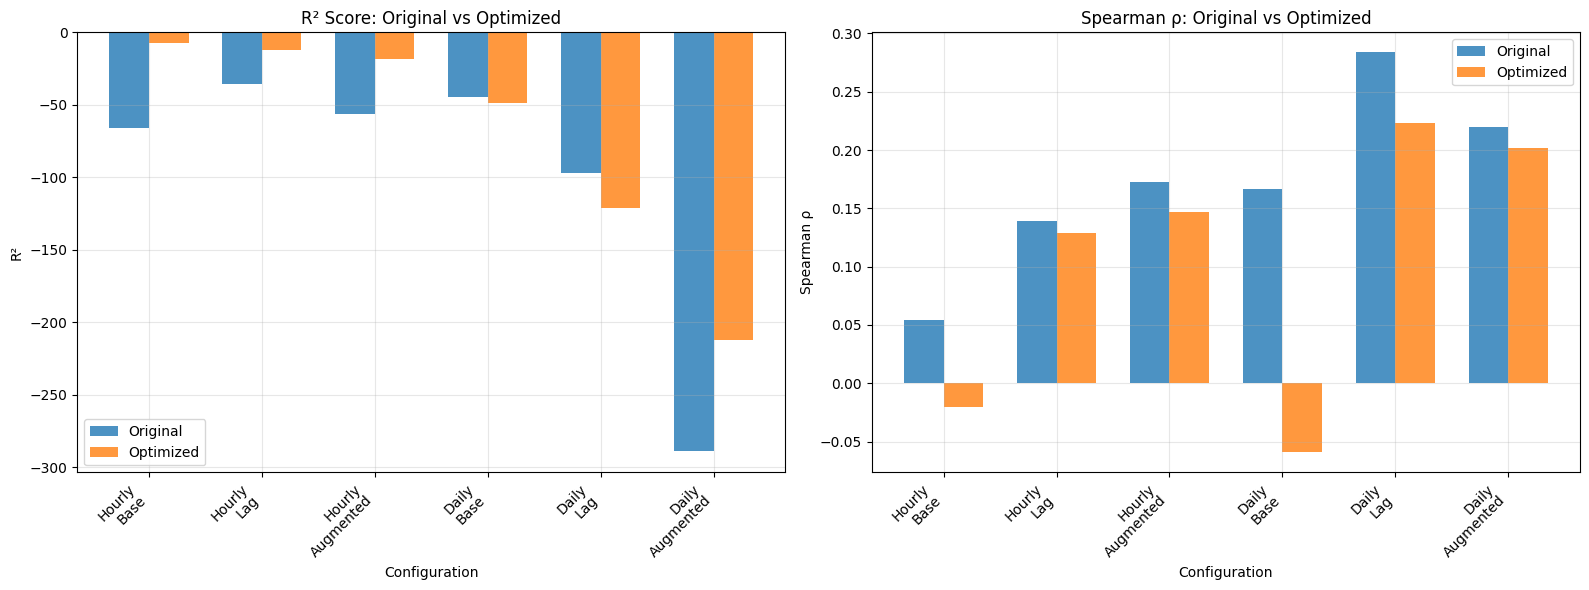

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save best parameters

In [19]:
# Define dataset name
dataset_name = "Tanikon"

# Create dataset subfolder inside existing xgboost_params folder
save_dir = os.path.join('xgboost_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to xgboost_params/Tanikon!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 30
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/xgboost_params/Tanikon

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +58.7241
Hourly          | Lag                  | ✓ OPTIMIZED  | ΔR²: +23.5490
Hourly          | Augmented            | ✓ OPTIMIZED  | ΔR²: +37.9833
Daily           | Base                 | ✓ ORIGINAL   | ΔR²: -4.1635
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -24.2101
Daily           | Augmented            | ✓ OPTIMIZED  | ΔR²: +76.7237
